# Transfer learning, embeddings y explicabilidad — Enfermedades de mandioca (v2: orientada a minimizar falsos negativos)

**Proyecto:** IC522 · Trabajo Final Integrador · **Alumno:** WLODECK, Fabricio Joaquín
**Datos:** 20 % del dataset filtrado (`datos\cambios 01 - no hojas\imagenes filtradas`, 26,304 imágenes)

**Objetivo de decisión.** Distinguir las 5 clases (cbb, cbsd, cgm, cmd, healthy), con una prioridad explícita: **no clasificar como `healthy` una planta enferma** (falso negativo). Un falso negativo deja sin tratar una enfermedad transmisible (mosca blanca / estacas infectadas); un falso positivo solo cuesta una inspección de más.

Este notebook implementa:

1. **Ítems 1-2** — Transfer learning con dos backbones preentrenados (MobileNetV2 y EfficientNet-B7), cabeza propia. En timm 1.0.30, `efficientnet_b7` no publica pesos preentrenados, por lo que se usa `tf_efficientnet_b7` (misma arquitectura B7, pesos oficiales `ra_in1k`).
2. **Desbalance** — pesos de clase (`balanced`, con `healthy` atenuado, ver cambio 5) en todos los entrenamientos.
3. **Splits** — subset 20 % → 80 % train+val (con val propio) / 20 % test; **test balanceado 60 por clase (300)**; el resto del test pool queda como **test extendido** (held-out).
4. **Augmentación** — RandomCrop + VFlip + HFlip + RandomRotate(15°) vs. control sin augmentación (4 runs: E1-E4).
5. **Ítem 3** — Fine-tuning de MobileNetV2, con evaluación **antes y después** (E5).
6. **Ítem 4** — Clasificadores clásicos (RandomForest, SVM, XGBoost) y un MLP sobre embeddings del backbone.
7. **Ítem 6** — Explicabilidad con **LIME** antes y después del fine-tuning + verificación de sesgos espurios.

## Cambios de la v2 respecto de la v1

| # | Cambio | Por qué |
|---|---|---|
| 1 | **Métrica primaria = recall de "enfermo"** (binarizado: cualquier clase ≠ healthy), junto con especificidad, AUC binaria e IC de Wilson. El macro-F1 queda como métrica secundaria (discriminación entre enfermedades) | macro-F1 penaliza igual cgm→cmd (error leve) que cgm→healthy (error grave) |
| 2 | Todas las evaluaciones guardan **probabilidades** (softmax / `predict_proba`) | permiten calibrar umbral, curvas ROC y ensambles |
| 3 | **Umbral de decisión `tau`** calibrado **solo en validación**: se predice `healthy` únicamente si P(healthy) > tau; entre enfermedades, argmax | mueve el punto de operación hacia recall alto sin reentrenar |
| 4 | Selección de checkpoint, early stopping y "mejor MV2" por **AUC binaria de validación** (independiente del umbral) | el criterio de selección queda alineado con el objetivo |
| 5 | Peso de `healthy` × `HEALTHY_W_FACTOR` en la loss y en los clasificadores clásicos | `balanced` le daba peso 1.82 a healthy (> cbsd 1.53), empujando al modelo a decir "sana" |
| 6 | **E5 corregido**: con augmentación, AdamW + weight decay, LR diferencial, cosine, label smoothing, descongelado **por bloques** y más épocas | en la v1 E5 heredó `aug=False`, sobreajustó (loss 0.22) y el val-F1 seguía subiendo al cortar |
| 7 | Evaluación adicional sobre `test_pool_rest` (≈752 imágenes held-out, no balanceadas) | más muestras → IC del recall más angostos (el recall no depende de la prevalencia) |
| 8 | **Ensamble** por promedio de probabilidades y **TTA** (flips) | reduce varianza; suele mejorar el recall |
| 9 | "Mejor modelo" elegido por **validación** (no por test); corregido el bug `posts`; el texto de LIME ya no está hardcodeado | rigor y reproducibilidad |

> **Caché:** los artefactos de la v2 usan el sufijo `_v2` (checkpoints y `*_res.json`) para no mezclarse con los de la v1. Los embeddings no cambian y reutilizan su caché.

## Fase 0 — Entorno, semillas y configuración

In [1]:
import os, sys, json, time, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from torchvision import transforms as T

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, balanced_accuracy_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from IPython.display import display, Markdown

SMOKE = os.environ.get("SMOKE", "0") == "1"
VER = "_v2"                                   # separa artefactos de la v1
TAG = VER + ("_smoke" if SMOKE else "")      # checkpoints y *_res.json
EMB_TAG = "_smoke" if SMOKE else ""          # los embeddings no cambian: reutilizan la caché v1

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("torch:", torch.__version__, "| timm:", timm.__version__)
print("device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("modo SMOKE:", SMOKE)

d:\final_inteligencia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.14.0+cu126 | timm: 1.0.30
device: cuda - NVIDIA GeForce GTX 1660 SUPER
modo SMOKE: False


In [2]:
BASE = Path("D:/final_inteligencia")
DIR_IMG = BASE / "datos" / "cambios 01 - no hojas" / "imagenes filtradas"
DIR_LABELS = BASE / "datos" / "cambios 01 - no hojas" / "labels_filtrado.csv"
DIR_SPLIT = BASE / "datos" / "splits"
MANIFEST = DIR_SPLIT / "manifest_20pct.csv"
DIR_MODEL = BASE / "modelos"
DIR_REPORT = BASE / "reportes"
DIR_SPLIT.mkdir(parents=True, exist_ok=True)
DIR_MODEL.mkdir(parents=True, exist_ok=True)
DIR_REPORT.mkdir(parents=True, exist_ok=True)

SEED = 42
FRAC_SUBSET, FRAC_TESTPOOL, FRAC_VAL = 0.20, 0.20, 0.20
MAX_TEST_PC = 60
CLASS_NAMES = ["cbb", "cbsd", "cgm", "cmd", "healthy"]
NUM_CLASSES = 5
HEALTHY = CLASS_NAMES.index("healthy")
ENF_IDX = [c for c in range(NUM_CLASSES) if c != HEALTHY]   # clases enfermas
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

# --- objetivo de decision (v2) ---
OBJ_RECALL = 0.95          # recall de "enfermo" que se exige en VALIDACION al calibrar tau
HEALTHY_W_FACTOR = 0.6     # atenua el peso de 'healthy' en la loss (hiperparametro a tunear: 0.4-1.0)

CONFIG = {
    "E1": dict(backbone="mobilenetv2_100", size=224, aug=False, epochs=20, batch=32, lr=1e-3, patience=4),
    "E2": dict(backbone="mobilenetv2_100", size=224, aug=True,  epochs=20, batch=32, lr=1e-3, patience=4),
    "E3": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=False, epochs=12, batch=4,  lr=1e-3, patience=4),
    "E4": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=True,  epochs=12, batch=4,  lr=1e-3, patience=4),
}
# Fine-tuning v2: augmentacion ON, LR diferencial, AdamW, cosine, label smoothing, descongelado por bloques
FT_CFG = dict(epochs=12, patience=4, aug=True, unfreeze_blocks=3,
              lr_backbone=1e-4, lr_head=3e-4, weight_decay=1e-2, label_smoothing=0.1)
LIME_SAMPLES = 500
LIME_POR_CLASE = 2

if SMOKE:
    for k in CONFIG:
        CONFIG[k].update(epochs=1, patience=1)
    CONFIG["E1"].update(batch=8)
    CONFIG["E2"].update(batch=8)
    CONFIG["E3"].update(batch=2)
    CONFIG["E4"].update(batch=2)
    FT_CFG.update(epochs=1, patience=1)
    LIME_SAMPLES, LIME_POR_CLASE = 60, 1

print(json.dumps({k: v for k, v in CONFIG.items()}, indent=1))
print("fine-tuning:", FT_CFG, "| LIME samples:", LIME_SAMPLES)
print("objetivo: recall enfermo >=", OBJ_RECALL, "| peso healthy x", HEALTHY_W_FACTOR)

{
 "E1": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": false,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E2": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": true,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E3": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": false,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 },
 "E4": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": true,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 }
}
fine-tuning: {'epochs': 12, 'patience': 4, 'aug': True, 'unfreeze_blocks': 3, 'lr_backbone': 0.0001, 'lr_head': 0.0003, 'weight_decay': 0.01, 'label_smoothing': 0.1} | LIME samples: 500
objetivo: recall enfermo >= 0.95 | peso healthy x 0.6


## Fase 1 — Datos: subset 20 %, train/val/test y test balanceado

Estratificación por **clase × source** (evita el sesgo de dominio 2019/2020, ver EDA §4.3), semilla 42:

1. subset = 20 % del dataset filtrado;
2. dentro del subset: 80 % train+val / 20 % test pool;
3. del train+val: 80 % train / 20 % val;
4. **test final balanceado**: 60 muestras por clase (limita CBB) muestreadas del test pool;
5. el resto del test pool queda **held-out** (no se entrena con él).

In [3]:
df_lab = pd.read_csv(DIR_LABELS)
df_lab["label_name"] = df_lab["label"].map(dict(enumerate(CLASS_NAMES)))
assert len(df_lab) == 26304 and df_lab["image_id"].is_unique

strata = df_lab["label"].astype(str) + "_" + df_lab["source"].astype(str)
subset_idx, _ = train_test_split(df_lab.index, train_size=FRAC_SUBSET, stratify=strata, random_state=SEED)

df_lab["split"] = "out_subset"
df_lab.loc[subset_idx, "split"] = "trainval"

sub = df_lab.loc[subset_idx]
strata_sub = sub["label"].astype(str) + "_" + sub["source"].astype(str)
trainval_idx, testpool_idx = train_test_split(sub.index, train_size=1 - FRAC_TESTPOOL,
                                              stratify=strata_sub, random_state=SEED)
df_lab.loc[testpool_idx, "split"] = "test_pool"

tv = df_lab.loc[trainval_idx]
strata_tv = tv["label"].astype(str) + "_" + tv["source"].astype(str)
train_idx, val_idx = train_test_split(tv.index, train_size=1 - FRAC_VAL,
                                      stratify=strata_tv, random_state=SEED)
df_lab.loc[train_idx, "split"] = "train"
df_lab.loc[val_idx, "split"] = "val"

pool = df_lab[df_lab["split"] == "test_pool"]
bal = pool.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(MAX_TEST_PC, len(g)), random_state=SEED), include_groups=False).index
df_lab.loc[df_lab.index.isin(bal), "split"] = "test"
df_lab.loc[df_lab["split"] == "test_pool", "split"] = "test_pool_rest"

In [4]:
print("== conteo por split ==")
print(df_lab["split"].value_counts().to_string())

ct = pd.crosstab(df_lab["label_name"], df_lab["split"])[["train", "val", "test", "test_pool_rest", "out_subset"]]
print("\n== clase x split ==")
display(ct)

print("== fuente x split ==")
display(pd.crosstab(df_lab["source"], df_lab["split"]))

assert len(df_lab) == 26304
s_tr = set(df_lab[df_lab.split == "train"]["image_id"])
s_va = set(df_lab[df_lab.split == "val"]["image_id"])
s_te = set(df_lab[df_lab.split == "test"]["image_id"])
assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
tc = df_lab[df_lab.split == "test"]["label"].value_counts().sort_index()
assert (tc == MAX_TEST_PC).all()
assert set(df_lab["split"]) == {"train", "val", "test", "test_pool_rest", "out_subset"}
print("OK: sin leakage | subset 20 % =", int((df_lab.split != "out_subset").sum()),
      "| test balanceado total =", int(tc.sum()))

manifest = df_lab[["image_id", "label", "label_name", "source", "split"]].copy()
if SMOKE:
    keep = set()
    for sp, n in [("train", 8), ("val", 4), ("test", 4)]:
        keep |= set(manifest[manifest.split == sp].groupby("label", group_keys=False).head(n).index)
    manifest.loc[~manifest.index.isin(keep), "split"] = "out_subset"
    print("SMOKE: train/val/test reducidos a 8/4/4 por clase")
    display(manifest[manifest.split != "out_subset"].groupby(["split", "label"]).size().unstack(0))

== conteo por split ==
split
out_subset        21044
train              3366
val                 842
test_pool_rest      752
test                300

== clase x split ==


split,train,val,test,test_pool_rest,out_subset
label_name,,,,,
cbb,191,48,60,0,1193
cbsd,440,110,60,78,2756
cgm,387,96,60,60,2414
cmd,1979,495,60,558,12370
healthy,369,93,60,56,2311


== fuente x split ==


split,out_subset,test,test_pool_rest,train,val
source,,,,,
2019,3952,61,137,632,158
2020,17092,239,615,2734,684


OK: sin leakage | subset 20 % = 5260 | test balanceado total = 300


manifest guardado en D:\final_inteligencia\datos\splits\manifest_20pct.csv


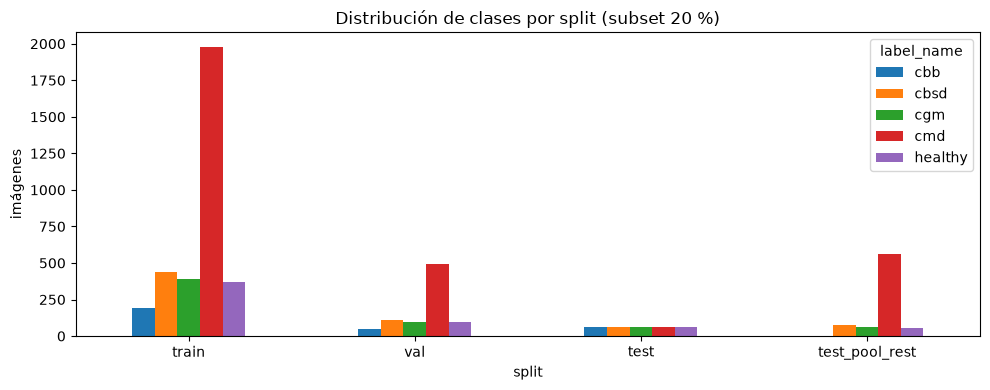

In [5]:
if not SMOKE:
    manifest.to_csv(MANIFEST, index=False)
    print("manifest guardado en", MANIFEST)
else:
    print("SMOKE: manifest NO se sobreescribe")

orden = ["train", "val", "test", "test_pool_rest", "out_subset"]
ct_plot = manifest[manifest.split != "out_subset"].groupby(["label_name", "split"]).size().unstack(0)[CLASS_NAMES]
ax = ct_plot.reindex(orden[:4]).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Distribución de clases por split (subset 20 %)")
ax.set_ylabel("imágenes"); ax.set_xlabel("split")
plt.tight_layout(); plt.show()

## Fase 2 — Infraestructura compartida

- **Transforms**: `Resize(256) + Crop(224)` (MobileNetV2) / `Resize(640) + Crop(600)` (EfficientNet-B7), sin deformar (EDA §4.4). Augmentación **solo** en train del brazo con aug: `RandomCrop`, `RandomVerticalFlip`, `RandomHorizontalFlip`, `RandomRotation(15°)`.
- **Pesos de clase** (`balanced`) calculados **solo sobre train**, con el peso de `healthy` multiplicado por `HEALTHY_W_FACTOR`.
- **Cabeza**: GAP del backbone → Dropout(0.3) → Linear(5).
- **Selección**: mejor época por **AUC binaria (enfermo vs. sano) de validación** + early stopping. El macro-F1 se sigue registrando.

In [6]:
def build_transforms(size, aug):
    base = T.Resize(256 if size == 224 else 640, interpolation=T.InterpolationMode.BILINEAR)
    crop = T.RandomCrop(size) if aug else T.CenterCrop(size)
    ops = [base, crop]
    if aug:
        ops += [T.RandomVerticalFlip(0.5),
                T.RandomHorizontalFlip(0.5),
                T.RandomRotation(15)]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

class MandiocaDataset(Dataset):
    def __init__(self, manifest_df, split, transform):
        self.df = manifest_df[manifest_df["split"] == split].reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(DIR_IMG / r["image_id"]).convert("RGB")
        return self.transform(img), int(r["label"])

tr_labels = manifest.loc[manifest.split == "train", "label"].values
pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_labels)
pesos_balanced = pesos.copy()
pesos[HEALTHY] *= HEALTHY_W_FACTOR                      # v2: atenuar 'healthy'
CW_DICT = {c: float(pesos[c]) for c in range(NUM_CLASSES)}   # para sklearn / xgboost
CLASS_W = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
print("pesos 'balanced'      :", {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(pesos_balanced)})
print("pesos usados (v2)     :", {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(pesos)})

tf_demo = build_transforms(224, True)
ds_demo = MandiocaDataset(manifest, "train", tf_demo)
x0, y0 = ds_demo[0]
print("batch ejemplo:", tuple(x0.shape), "| clase:", CLASS_NAMES[y0])

pesos 'balanced'      : {'cbb': 3.525, 'cbsd': 1.53, 'cgm': 1.74, 'cmd': 0.34, 'healthy': 1.824}
pesos usados (v2)     : {'cbb': 3.525, 'cbsd': 1.53, 'cgm': 1.74, 'cmd': 0.34, 'healthy': 1.095}
batch ejemplo: (3, 224, 224) | clase: cmd


## Fase 2b — Métricas orientadas a falsos negativos

Se binariza el problema solo **para evaluar**: `enfermo` = cualquiera de cbb/cbsd/cgm/cmd, `sano` = healthy. El modelo sigue prediciendo las 5 clases.

- **Recall enfermo** (= 1 − FNR): fracción de plantas enfermas que **no** se predicen como `healthy`. Es la métrica primaria.
- **Especificidad**: fracción de plantas sanas que se predicen `healthy`. Es el costo que se paga por subir el recall (si solo se optimizara recall, "todo enfermo" sería perfecto).
- **AUC binaria**: calidad del score `1 − P(healthy)` independientemente del umbral.
- **FN por clase**: % de cada enfermedad que cae en `healthy` (muestra qué enfermedad se escapa más).
- **IC de Wilson 95 %** del recall: con 240 enfermas en el test, ±4 puntos no es raro; diferencias menores no son concluyentes.
- **Umbral `tau`**: se predice `healthy` solo si `P(healthy) > tau`; en caso contrario se elige la enfermedad con mayor probabilidad. `tau` se calibra en **validación** como el menor valor que cumple `recall_enf ≥ OBJ_RECALL` (maximiza la especificidad bajo esa restricción) y se aplica **sin tocar** a test.
- **macro-F1 de 5 clases** se mantiene como métrica secundaria.

In [7]:
class Clf(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.head = nn.Sequential(nn.Dropout(0.3),
                                  nn.Linear(self.backbone.num_features, NUM_CLASSES))
    def train(self, mode=True):
        super().train(mode)
        if mode:
            self.backbone.eval()     # BN/dropout del backbone siempre en eval (batches chicos)
        return self
    def forward(self, x):
        return self.head(self.backbone(x))
    def featurizador(self, x):
        return self.backbone(x)


# ---------- metricas orientadas a falsos negativos ----------
def wilson(k, n, z=1.96):
    if n == 0:
        return float("nan"), float("nan")
    p = k / n
    den = 1 + z ** 2 / n
    centro = (p + z ** 2 / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return centro - half, centro + half


def metricas_fn(y_true, y_pred):
    # Binariza (enfermo vs sano) y devuelve recall, especificidad, IC y FN por clase.
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    enf, pred_enf = y_true != HEALTHY, y_pred != HEALTHY
    tp = int((enf & pred_enf).sum()); fn = int((enf & ~pred_enf).sum())
    tn = int((~enf & ~pred_enf).sum()); fp = int((~enf & pred_enf).sum())
    rec = tp / (tp + fn) if (tp + fn) else float("nan")
    esp = tn / (tn + fp) if (tn + fp) else float("nan")
    lo, hi = wilson(tp, tp + fn)
    fn_clase = {CLASS_NAMES[c]: (float((y_pred[y_true == c] == HEALTHY).mean()) if (y_true == c).any() else float("nan"))
                for c in ENF_IDX}
    return dict(recall_enf=rec, fnr=1 - rec, recall_enf_ic=[lo, hi], especificidad=esp,
                tp=tp, fn=fn, tn=tn, fp=fp, fn_por_clase=fn_clase)


def predecir_con_umbral(probs, tau):
    # 'healthy' solo si P(healthy) > tau; si no, argmax entre las 4 enfermedades.
    probs = np.asarray(probs)
    pred = np.array(ENF_IDX)[probs[:, ENF_IDX].argmax(1)]
    pred[probs[:, HEALTHY] > tau] = HEALTHY
    return pred


def elegir_tau(p_val, y_val, objetivo=OBJ_RECALL):
    # Menor tau (mayor especificidad) tal que recall_enf en validacion >= objetivo.
    # El recall es monotono creciente en tau, asi que el primer tau que cumple es el optimo.
    for tau in np.linspace(0.01, 0.99, 99):
        if metricas_fn(y_val, predecir_con_umbral(p_val, tau))["recall_enf"] >= objetivo:
            return float(tau)
    return 0.99


def calc_metricas(y_true, probs):
    # Metricas completas a partir de probabilidades (argmax = decision por defecto).
    y_true = np.asarray(y_true); probs = np.asarray(probs, dtype=np.float64)
    y_pred = probs.argmax(1)
    per = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    enf = (y_true != HEALTHY).astype(int)
    auc = roc_auc_score(enf, 1 - probs[:, HEALTHY]) if enf.min() != enf.max() else float("nan")
    out = dict(f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
               f1_per_class=[float(v) for v in per],
               balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
               auc_enf=float(auc),
               y_true=y_true.tolist(), y_pred=y_pred.tolist(),
               probs=np.round(probs, 5).tolist())
    out.update(metricas_fn(y_true, y_pred))
    return out


@torch.no_grad()
def probs_modelo(model, dataset, batch_size=64, tta=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        p = torch.softmax(model(x).float(), 1)
        if tta:   # promedio original + flip horizontal + flip vertical
            p = (p + torch.softmax(model(torch.flip(x, dims=[3])).float(), 1)
                   + torch.softmax(model(torch.flip(x, dims=[2])).float(), 1)) / 3
        ps.append(p.cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)


def evaluar(model, dataset, batch_size=64, tta=False):
    if len(dataset) == 0:     # p.ej. test_pool_rest vacio en modo SMOKE
        return None
    y, p = probs_modelo(model, dataset, batch_size, tta)
    return calc_metricas(y, p)


def eval_batch(cfg):
    if cfg["size"] == 224:
        return max(cfg["batch"], 32)
    return 8

In [8]:
def entrenar(exp_id, cfg):
    ckpt = DIR_MODEL / f"{exp_id}{TAG}.pth"
    res_path = DIR_MODEL / f"{exp_id}{TAG}_res.json"
    if ckpt.exists() and res_path.exists():
        print(f"[cache] {exp_id} ya entrenado")
        return json.loads(res_path.read_text(encoding="utf-8"))

    set_seed()
    tf_ev = build_transforms(cfg["size"], False)
    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], cfg["aug"]))
    ds_va = MandiocaDataset(manifest, "val", tf_ev)
    ds_te = MandiocaDataset(manifest, "test", tf_ev)
    ds_ex = MandiocaDataset(manifest, "test_pool_rest", tf_ev)     # test extendido (held-out)
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    model = Clf(cfg["backbone"]).to(DEVICE)
    for p in model.backbone.parameters():
        p.requires_grad = False
    model.eval()
    with torch.no_grad():
        f0 = model.backbone(torch.zeros(2, 3, cfg["size"], cfg["size"], device=DEVICE))
        print(f"{exp_id}: sanity feats_nan={torch.isnan(f0).any().item()}", flush=True)
    n_params = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg["lr"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    print(f"{exp_id}: train={len(ds_tr)} val={len(ds_va)} test={len(ds_te)} test_ext={len(ds_ex)} "
          f"params={n_params:,} (entrenables={n_train:,})", flush=True)
    best_auc, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                print(f"  [{exp_id}] loss no finita en ep{ep}, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += loss.item() * len(y)
            n_seen += len(y)
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / max(n_seen, 1), 4),
                            val_f1=round(ev["f1_macro"], 4), val_auc=round(ev["auc_enf"], 4),
                            val_recall_enf=round(ev["recall_enf"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  ep{ep}/{cfg['epochs']} loss={history[-1]['train_loss']:.4f} valAUC={ev['auc_enf']:.4f} "
              f"valF1={ev['f1_macro']:.4f} valRecEnf={ev['recall_enf']:.3f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["auc_enf"] > best_auc + 1e-4:          # v2: criterio = AUC binaria enfermo-vs-sano
            best_auc, wait = ev["auc_enf"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt)
    model.load_state_dict(best_state)
    bs = eval_batch(cfg)
    va, te, ex = evaluar(model, ds_va, bs), evaluar(model, ds_te, bs), evaluar(model, ds_ex, bs)
    res = dict(id=exp_id, metodo="transfer learning (cabeza)", backbone=cfg["backbone"],
               size=cfg["size"], aug=cfg["aug"], epochs_run=len(history),
               params=n_params, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               criterio_seleccion="auc_enf_val", val=va, test=te, test_ext=ex, history=history)
    res_path.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"{exp_id} listo: valAUC={va['auc_enf']:.4f} testF1={te['f1_macro']:.4f} "
          f"testRecEnf(argmax)={te['recall_enf']:.3f} ({res['tiempo_total_s']}s)")
    return res

RESULTADOS = {}

## Fase 3 — Experimentos de transfer learning (E1-E4)

| ID | Backbone | Input | Augmentación |
|---|---|---|---|
| E1 | MobileNetV2 | 224 | no |
| E2 | MobileNetV2 | 224 | **sí** (RandomCrop+VFlip+HFlip+Rotate) |
| E3 | EfficientNet-B7 | 600 | no |
| E4 | EfficientNet-B7 | 600 | **sí** |

In [9]:
RESULTADOS["E1"] = entrenar("E1", CONFIG["E1"])

E1: sanity feats_nan=False
E1: train=3366 val=842 test=300 test_ext=752 params=2,230,277 (entrenables=6,405)
  ep1/20 loss=1.2933 valAUC=0.8613 valF1=0.5181 valRecEnf=0.972 (129.1s)
  ep2/20 loss=1.0601 valAUC=0.8866 valF1=0.5890 valRecEnf=0.949 (101.7s)
  ep3/20 loss=0.9751 valAUC=0.8855 valF1=0.5556 valRecEnf=0.964 (74.9s)
  ep4/20 loss=0.9241 valAUC=0.8894 valF1=0.5785 valRecEnf=0.948 (64.0s)
  ep5/20 loss=0.8939 valAUC=0.8951 valF1=0.5657 valRecEnf=0.947 (53.9s)
  ep6/20 loss=0.8533 valAUC=0.8968 valF1=0.6069 valRecEnf=0.933 (48.1s)
  ep7/20 loss=0.8412 valAUC=0.8949 valF1=0.5342 valRecEnf=0.955 (43.2s)
  ep8/20 loss=0.8067 valAUC=0.9004 valF1=0.5955 valRecEnf=0.939 (42.2s)
  ep9/20 loss=0.7976 valAUC=0.8955 valF1=0.5637 valRecEnf=0.964 (41.7s)
  ep10/20 loss=0.7744 valAUC=0.9008 valF1=0.5962 valRecEnf=0.941 (41.4s)
  ep11/20 loss=0.7753 valAUC=0.9007 valF1=0.6011 valRecEnf=0.944 (45.1s)
  ep12/20 loss=0.7681 valAUC=0.9022 valF1=0.6077 valRecEnf=0.960 (44.6s)
  ep13/20 loss=0.7493 

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [10]:
RESULTADOS["E2"] = entrenar("E2", CONFIG["E2"])

E2: sanity feats_nan=False
E2: train=3366 val=842 test=300 test_ext=752 params=2,230,277 (entrenables=6,405)
  ep1/20 loss=1.3388 valAUC=0.8520 valF1=0.4778 valRecEnf=0.940 (44.5s)
  ep2/20 loss=1.1542 valAUC=0.8752 valF1=0.5268 valRecEnf=0.865 (43.8s)
  ep3/20 loss=1.0917 valAUC=0.8763 valF1=0.5342 valRecEnf=0.937 (43.0s)
  ep4/20 loss=1.0479 valAUC=0.8782 valF1=0.5522 valRecEnf=0.903 (43.5s)
  ep5/20 loss=1.0354 valAUC=0.8848 valF1=0.5181 valRecEnf=0.909 (43.4s)
  ep6/20 loss=0.9835 valAUC=0.8850 valF1=0.5460 valRecEnf=0.832 (44.6s)
  ep7/20 loss=0.9970 valAUC=0.8867 valF1=0.4783 valRecEnf=0.904 (43.2s)
  ep8/20 loss=0.9791 valAUC=0.8917 valF1=0.5705 valRecEnf=0.892 (44.8s)
  ep9/20 loss=0.9586 valAUC=0.8846 valF1=0.5003 valRecEnf=0.949 (43.7s)
  ep10/20 loss=0.9508 valAUC=0.8902 valF1=0.5575 valRecEnf=0.927 (43.4s)
  ep11/20 loss=0.9299 valAUC=0.8920 valF1=0.5628 valRecEnf=0.907 (43.3s)
  ep12/20 loss=0.9430 valAUC=0.8959 valF1=0.5961 valRecEnf=0.915 (43.1s)
  ep13/20 loss=0.9472 va

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [11]:
RESULTADOS["E3"] = entrenar("E3", CONFIG["E3"])

E3: sanity feats_nan=False
E3: train=3366 val=842 test=300 test_ext=752 params=63,799,765 (entrenables=12,805)
  ep1/12 loss=1.0838 valAUC=0.8985 valF1=0.5900 valRecEnf=0.968 (628.6s)
  ep2/12 loss=0.8837 valAUC=0.9127 valF1=0.6129 valRecEnf=0.972 (616.7s)
  ep3/12 loss=0.8112 valAUC=0.9121 valF1=0.6559 valRecEnf=0.949 (616.8s)
  ep4/12 loss=0.7828 valAUC=0.9152 valF1=0.6374 valRecEnf=0.924 (616.1s)
  ep5/12 loss=0.7564 valAUC=0.9190 valF1=0.6251 valRecEnf=0.948 (614.6s)
  ep6/12 loss=0.7070 valAUC=0.9156 valF1=0.5815 valRecEnf=0.981 (614.5s)
  ep7/12 loss=0.6934 valAUC=0.9086 valF1=0.5922 valRecEnf=0.975 (613.4s)
  ep8/12 loss=0.6773 valAUC=0.9148 valF1=0.6193 valRecEnf=0.972 (614.5s)
  ep9/12 loss=0.6547 valAUC=0.9128 valF1=0.6498 valRecEnf=0.963 (613.6s)
  early stopping
E3 listo: valAUC=0.9190 testF1=0.6209 testRecEnf(argmax)=0.912 (5694.9s)


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [12]:
RESULTADOS["E4"] = entrenar("E4", CONFIG["E4"])

E4: sanity feats_nan=False
E4: train=3366 val=842 test=300 test_ext=752 params=63,799,765 (entrenables=12,805)
  ep1/12 loss=1.0923 valAUC=0.9048 valF1=0.5792 valRecEnf=0.971 (621.3s)
  ep2/12 loss=0.9108 valAUC=0.9107 valF1=0.5992 valRecEnf=0.964 (621.4s)
  ep3/12 loss=0.8542 valAUC=0.9114 valF1=0.6457 valRecEnf=0.928 (635.7s)
  ep4/12 loss=0.8331 valAUC=0.9161 valF1=0.6337 valRecEnf=0.949 (634.8s)
  ep5/12 loss=0.8168 valAUC=0.9270 valF1=0.6312 valRecEnf=0.960 (621.3s)
  ep6/12 loss=0.7817 valAUC=0.9119 valF1=0.6163 valRecEnf=0.967 (622.3s)
  ep7/12 loss=0.7750 valAUC=0.9102 valF1=0.5663 valRecEnf=0.983 (625.2s)
  ep8/12 loss=0.7565 valAUC=0.9196 valF1=0.6334 valRecEnf=0.971 (624.9s)
  ep9/12 loss=0.7311 valAUC=0.9123 valF1=0.6263 valRecEnf=0.972 (624.3s)
  early stopping
E4 listo: valAUC=0.9270 testF1=0.6235 testRecEnf(argmax)=0.938 (5783.0s)


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


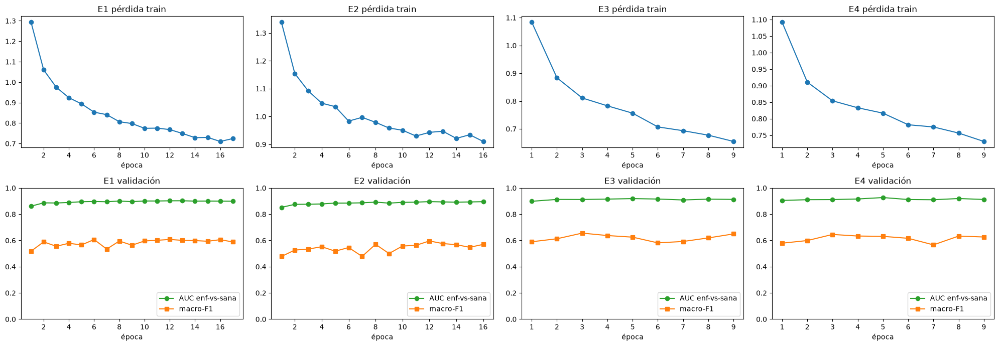

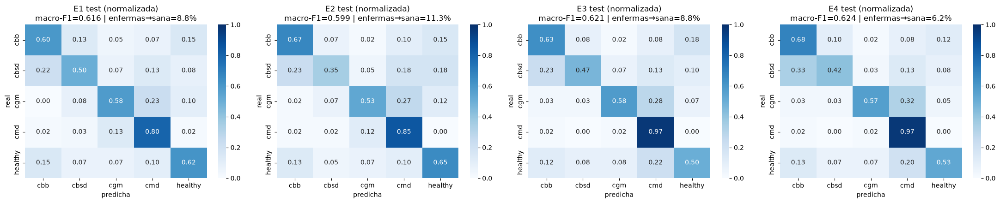

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    h = pd.DataFrame(RESULTADOS[eid]["history"])
    axes[0, j].plot(h["epoch"], h["train_loss"], marker="o")
    axes[0, j].set_title(f"{eid} pérdida train"); axes[0, j].set_xlabel("época")
    axes[1, j].plot(h["epoch"], h["val_auc"], marker="o", color="tab:green", label="AUC enf-vs-sana")
    axes[1, j].plot(h["epoch"], h["val_f1"], marker="s", color="tab:orange", label="macro-F1")
    axes[1, j].set_title(f"{eid} validación"); axes[1, j].set_xlabel("época")
    axes[1, j].set_ylim(0, 1); axes[1, j].legend(loc="lower right")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    te = RESULTADOS[eid]["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[j],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[j].set_title(f"{eid} test (normalizada)\nmacro-F1={te['f1_macro']:.3f} | enfermas→sana={te['fnr']:.1%}")
    axes[j].set_xlabel("predicha"); axes[j].set_ylabel("real")
plt.tight_layout(); plt.show()

In [14]:
filas = []
for eid in ["E1", "E2", "E3", "E4"]:
    r = RESULTADOS[eid]
    filas.append(dict(ID=eid, Backbone=r["backbone"], Input=r["size"],
                      Aug="si" if r["aug"] else "no", Epocas=r["epochs_run"],
                      F1_val=r["val"]["f1_macro"], AUC_val=r["val"]["auc_enf"],
                      F1_test=r["test"]["f1_macro"], AUC_test=r["test"]["auc_enf"],
                      Rec_enf=r["test"]["recall_enf"], Esp=r["test"]["especificidad"],
                      Enf_a_sana=r["test"]["fnr"], Params=r["params"], s_epoc=r["tiempo_ep_s"]))
tabla_e = pd.DataFrame(filas)
display(tabla_e.round(4))
print("FN por clase (test, argmax) -> % que cae en 'healthy':")
display(pd.DataFrame({eid: RESULTADOS[eid]["test"]["fn_por_clase"] for eid in ["E1", "E2", "E3", "E4"]}).round(3))

,ID,Backbone,Input,Aug,Epocas,F1_val,AUC_val,F1_test,AUC_test,Rec_enf,Esp,Enf_a_sana,Params,s_epoc
0,E1,mobilenetv2_100,224,no,17,0.6006,0.9025,0.6165,0.8451,0.9125,0.6167,0.0875,2230277,55.8
1,E2,mobilenetv2_100,224,si,16,0.5961,0.8959,0.5988,0.8444,0.8875,0.6500,0.1125,2230277,43.6
2,E3,tf_efficientnet_b7.ra_in1k,600,no,9,0.6251,0.9190,0.6209,0.8515,0.9125,0.5000,0.0875,63799765,616.5
3,E4,tf_efficientnet_b7.ra_in1k,600,si,9,0.6312,0.9270,0.6235,0.8565,0.9375,0.5333,0.0625,63799765,625.7


FN por clase (test, argmax) -> % que cae en 'healthy':


,E1,E2,E3,E4
cbb,0.150,0.150,0.183,0.117
cbsd,0.083,0.183,0.100,0.083
cgm,0.100,0.117,0.067,0.050
cmd,0.017,0.000,0.000,0.000


## Fase 4 — Fine-tuning de MobileNetV2 (E5): evaluación antes / después

- Se elige el mejor de E1/E2 por **AUC binaria de validación** → **checkpoint A = "antes"**.
- v2: se descongelan los **últimos `unfreeze_blocks` bloques** del backbone (+ `conv_head` y `bn2`) en vez de "el 30 % de los tensores" (que podía cortar un bloque a la mitad). El head siempre es entrenable.
- v2: **con augmentación**, **AdamW** (weight decay), **LR diferencial** (backbone 1e-4 / head 3e-4), **cosine**, **label smoothing**, hasta 12 épocas con early stopping. En la v1 E5 heredó `aug=False` de E1 y se cortó por límite de épocas con la validación todavía mejorando.
- **Checkpoint B = "después"**; A y B se evalúan con la **misma función** sobre val, test balanceado y test extendido.

In [15]:
mv2_ids = ["E1", "E2"]
mejor_mv2 = max(mv2_ids, key=lambda i: RESULTADOS[i]["val"]["auc_enf"])
print("mejor config MobileNetV2 (por AUC val):", mejor_mv2,
      "| AUC val =", round(RESULTADOS[mejor_mv2]["val"]["auc_enf"], 4))


def descongelar_bloques(model, n_blocks):
    for p in model.parameters():
        p.requires_grad = False
    bb = model.backbone
    partes = list(bb.blocks)[-n_blocks:]
    extras = [getattr(bb, nm) for nm in ("conv_head", "bn2") if hasattr(bb, nm)]
    for m in partes + extras:
        for p in m.parameters():
            p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True


def fine_tuning(exp_antes):
    ckpt_b = DIR_MODEL / f"E5{TAG}.pth"
    res_b = DIR_MODEL / f"E5{TAG}_res.json"
    if ckpt_b.exists() and res_b.exists():
        print("[cache] E5 ya entrenado")
        return json.loads(res_b.read_text(encoding="utf-8"))

    set_seed()
    cfg = CONFIG[exp_antes]
    model = Clf(cfg["backbone"]).to(DEVICE)
    model.load_state_dict(torch.load(DIR_MODEL / f"{exp_antes}{TAG}.pth", map_location=DEVICE))
    descongelar_bloques(model, FT_CFG["unfreeze_blocks"])
    n_ent = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"descongelados los ultimos {FT_CFG['unfreeze_blocks']} bloques (+conv_head/bn2) -> "
          f"{n_ent:,} params entrenables de {n_tot:,}")

    tf_ev = build_transforms(cfg["size"], False)
    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], FT_CFG["aug"]))
    ds_va = MandiocaDataset(manifest, "val", tf_ev)
    ds_te = MandiocaDataset(manifest, "test", tf_ev)
    ds_ex = MandiocaDataset(manifest, "test_pool_rest", tf_ev)
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    bb_params = [p for p in model.backbone.parameters() if p.requires_grad]
    opt = torch.optim.AdamW([dict(params=bb_params, lr=FT_CFG["lr_backbone"]),
                             dict(params=list(model.head.parameters()), lr=FT_CFG["lr_head"])],
                            weight_decay=FT_CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_CFG["epochs"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W, label_smoothing=FT_CFG["label_smoothing"])
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_auc, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, FT_CFG["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                print("  [E5] loss no finita, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += loss.item() * len(y)
            n_seen += len(y)
        sched.step()
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / max(n_seen, 1), 4),
                            val_f1=round(ev["f1_macro"], 4), val_auc=round(ev["auc_enf"], 4),
                            val_recall_enf=round(ev["recall_enf"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  FT ep{ep}/{FT_CFG['epochs']} loss={history[-1]['train_loss']:.4f} valAUC={ev['auc_enf']:.4f} "
              f"valF1={ev['f1_macro']:.4f} valRecEnf={ev['recall_enf']:.3f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["auc_enf"] > best_auc + 1e-4:
            best_auc, wait = ev["auc_enf"], 0
            best_state = {kk: v.detach().cpu().clone() for kk, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= FT_CFG["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt_b)
    model.load_state_dict(best_state)
    bs = eval_batch(cfg)
    va, te, ex = evaluar(model, ds_va, bs), evaluar(model, ds_te, bs), evaluar(model, ds_ex, bs)
    res = dict(id="E5", metodo="fine-tuning MV2 (ultimos bloques)", backbone=cfg["backbone"],
               size=cfg["size"], aug=FT_CFG["aug"], epochs_run=len(history),
               params=n_ent, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               antes=exp_antes, criterio_seleccion="auc_enf_val", ft_cfg=FT_CFG,
               val=va, test=te, test_ext=ex, history=history)
    res_b.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"E5 listo: valAUC={va['auc_enf']:.4f} testF1={te['f1_macro']:.4f} testRecEnf(argmax)={te['recall_enf']:.3f}")
    return res

RESULTADOS["E5"] = fine_tuning(mejor_mv2)
print("AUC val antes:", round(RESULTADOS[mejor_mv2]["val"]["auc_enf"], 4),
      "| despues:", round(RESULTADOS["E5"]["val"]["auc_enf"], 4))

mejor config MobileNetV2 (por AUC val): E1 | AUC val = 0.9025
descongelados los ultimos 3 bloques (+conv_head/bn2) -> 1,990,917 params entrenables de 2,230,277
  FT ep1/12 loss=1.3765 valAUC=0.8841 valF1=0.5682 valRecEnf=0.917 (55.2s)
  FT ep2/12 loss=1.2797 valAUC=0.9054 valF1=0.6229 valRecEnf=0.953 (47.9s)
  FT ep3/12 loss=1.2106 valAUC=0.9095 valF1=0.6106 valRecEnf=0.960 (47.5s)
  FT ep4/12 loss=1.1817 valAUC=0.9094 valF1=0.5471 valRecEnf=0.924 (47.6s)
  FT ep5/12 loss=1.1168 valAUC=0.9177 valF1=0.5946 valRecEnf=0.948 (47.4s)
  FT ep6/12 loss=1.0758 valAUC=0.9206 valF1=0.6394 valRecEnf=0.937 (47.2s)
  FT ep7/12 loss=1.0544 valAUC=0.9328 valF1=0.6202 valRecEnf=0.964 (47.5s)
  FT ep8/12 loss=1.0137 valAUC=0.9381 valF1=0.6453 valRecEnf=0.941 (47.4s)
  FT ep9/12 loss=0.9865 valAUC=0.9255 valF1=0.5809 valRecEnf=0.955 (47.6s)
  FT ep10/12 loss=0.9680 valAUC=0.9340 valF1=0.6319 valRecEnf=0.933 (47.5s)
  FT ep11/12 loss=0.9581 valAUC=0.9331 valF1=0.6425 valRecEnf=0.943 (47.3s)
  FT ep12/12 

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Estado,Back,F1_val,AUC_val,F1_test,AUC_test,Rec_enf,Esp,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy,BalAcc
0,E1 (antes FT),cabeza congelada,0.6006,0.9025,0.6165,0.8451,0.9125,0.6167,0.6050,0.5505,0.6140,0.6857,0.6271,0.6200
1,E5 (despues FT),fine-tuning por bloques,0.6453,0.9381,0.6502,0.8450,0.8875,0.5667,0.6154,0.6168,0.6992,0.7576,0.5620,0.6533


delta test macro-F1: 0.0337 | delta recall enfermo (argmax): -0.025


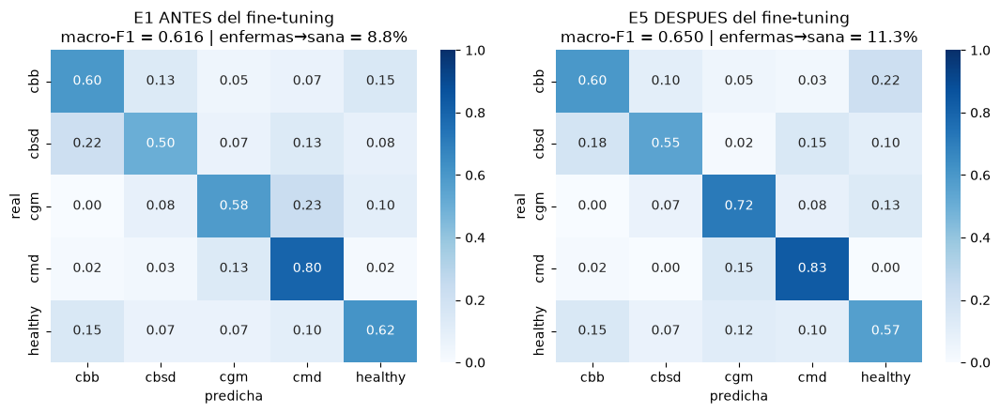

In [16]:
res_antes, res_des = RESULTADOS[mejor_mv2], RESULTADOS["E5"]
filas = []
for etiqueta, estado, r in [(f"{mejor_mv2} (antes FT)", "cabeza congelada", res_antes),
                            ("E5 (despues FT)", "fine-tuning por bloques", res_des)]:
    filas.append(dict(Estado=etiqueta, Back=estado, F1_val=r["val"]["f1_macro"], AUC_val=r["val"]["auc_enf"],
                      F1_test=r["test"]["f1_macro"], AUC_test=r["test"]["auc_enf"],
                      Rec_enf=r["test"]["recall_enf"], Esp=r["test"]["especificidad"],
                      **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)},
                      BalAcc=r["test"]["balanced_acc"]))
tabla_ab = pd.DataFrame(filas)
display(tabla_ab.round(4))
print("delta test macro-F1:", round(res_des["test"]["f1_macro"] - res_antes["test"]["f1_macro"], 4),
      "| delta recall enfermo (argmax):", round(res_des["test"]["recall_enf"] - res_antes["test"]["recall_enf"], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (titulo, r) in zip(axes, [(f"{mejor_mv2} ANTES del fine-tuning", res_antes),
                                  ("E5 DESPUES del fine-tuning", res_des)]):
    te = r["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{titulo}\nmacro-F1 = {te['f1_macro']:.3f} | enfermas→sana = {te['fnr']:.1%}")
    ax.set_xlabel("predicha"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()

## Fase 5 — Ítem 4: embeddings + clasificadores clásicos (y una red sobre embeddings)

- Features = salida del **GAP del backbone ImageNet congelado** (sin head), mismas transformaciones de evaluación; se cachean en `.npz` (se reutilizan los de la v1; solo se extrae el split nuevo `test_pool_rest`).
- Clasificadores: **RandomForest**, **SVM RBF** (grid chico C/γ elegido por **AUC binaria en val**, luego reentrenado con `probability=True`), **XGBoost** y un **MLP**. Todos con los **mismos pesos de clase v2** (`CW_DICT`) y devolviendo **probabilidades**, para poder calibrar `tau` igual que en las redes end-to-end.

In [17]:
@torch.no_grad()
def extraer_embeddings(backbone_name, size, split):
    cache = DIR_MODEL / f"emb_{backbone_name}_{split}{EMB_TAG}.npz"
    if cache.exists():
        d = np.load(cache)
        print(f"[cache] emb {backbone_name} {split}: {d['X'].shape}")
        return d["X"], d["y"]
    ds = MandiocaDataset(manifest, split, build_transforms(size, False))
    if len(ds) == 0:
        return np.zeros((0, 1), np.float32), np.zeros(0, dtype=int)
    model = Clf(backbone_name).to(DEVICE)
    model.eval()
    dl = DataLoader(ds, batch_size=8 if size == 600 else 64, shuffle=False, num_workers=0)
    feats, labs = [], []
    for x, y in dl:
        f = model.featurizador(x.to(DEVICE)).float().cpu().numpy()
        feats.append(f); labs.append(y.numpy())
    X = np.concatenate(feats).astype(np.float32)
    y = np.concatenate(labs)
    np.savez_compressed(cache, X=X, y=y)
    print(f"emb {backbone_name} {split}: {X.shape}")
    return X, y

EMB = {}
for bb_name, bb_size in [("mobilenetv2_100", 224), ("tf_efficientnet_b7.ra_in1k", 600)]:
    EMB[bb_name] = {}
    for clave, sp in [("train", "train"), ("val", "val"), ("test", "test"), ("ext", "test_pool_rest")]:
        EMB[bb_name][clave] = extraer_embeddings(bb_name, bb_size, sp)
    assert EMB[bb_name]["train"][1].shape[0] == int((manifest.split == "train").sum())

[cache] emb mobilenetv2_100 train: (3366, 1280)
[cache] emb mobilenetv2_100 val: (842, 1280)
[cache] emb mobilenetv2_100 test: (300, 1280)
emb mobilenetv2_100 test_pool_rest: (752, 1280)
[cache] emb tf_efficientnet_b7.ra_in1k train: (3366, 2560)
[cache] emb tf_efficientnet_b7.ra_in1k val: (842, 2560)
[cache] emb tf_efficientnet_b7.ra_in1k test: (300, 2560)
emb tf_efficientnet_b7.ra_in1k test_pool_rest: (752, 2560)


In [18]:
def bb_key(name):
    return "mobilenetv2" if name.startswith("mobilenet") else "efficientnet"

def metricas_sklearn(y_true, probs):
    return calc_metricas(y_true, probs)

def metricas_ext(y_ext, probs_ext):
    return calc_metricas(y_ext, probs_ext) if len(y_ext) else None

def registrar_ml(exp_id, metodo, backbone, extra, val_m, test_m, params, t_s, ext_m=None):
    res = dict(id=exp_id, metodo=metodo, backbone=backbone, size=None, aug=None,
               epochs_run=None, params=params, tiempo_total_s=round(t_s, 1),
               tiempo_ep_s=None, extra=extra, val=val_m, test=test_m, test_ext=ext_m)
    (DIR_MODEL / f"{exp_id}{TAG}_res.json").write_text(json.dumps(res, indent=1), encoding="utf-8")
    return res

def pesos_balanceados(y):
    return np.array([CW_DICT[int(c)] for c in y])

In [19]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    Xe, ye = EMB[bb_name]["ext"]
    t0 = time.time()
    clf = RandomForestClassifier(n_estimators=500, class_weight=CW_DICT,
                                 random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, ytr)
    res = registrar_ml(f"E6_{bb_key(bb_name)}", "RandomForest", bb_name, "n=500",
                       metricas_sklearn(yv, clf.predict_proba(Xv)),
                       metricas_sklearn(yt, clf.predict_proba(Xt)),
                       500, time.time() - t0,
                       ext_m=metricas_ext(ye, clf.predict_proba(Xe)) if len(ye) else None)
    print(bb_name, "RF test F1 =", round(res["test"]["f1_macro"], 4), "| AUC enf =", round(res["test"]["auc_enf"], 4))

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


mobilenetv2_100 RF test F1 = 0.4927 | AUC enf = 0.8093
tf_efficientnet_b7.ra_in1k RF test F1 = 0.5298 | AUC enf = 0.808


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [20]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    Xe, ye = EMB[bb_name]["ext"]
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    Xe_s = sc.transform(Xe) if len(ye) else Xe
    enf_v = (yv != HEALTHY).astype(int)
    mejor = None
    t0 = time.time()
    for C in [1, 10]:
        for gamma in ["scale", 1e-3]:
            clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight=CW_DICT, random_state=SEED)
            clf.fit(Xtr_s, ytr)
            # seleccion por AUC binaria: score de "enfermo" = -decision_function[healthy]
            auc_v = roc_auc_score(enf_v, -clf.decision_function(Xv_s)[:, HEALTHY])
            f1v = f1_score(yv, clf.predict(Xv_s), average="macro", zero_division=0)
            print(f"  {bb_name} SVM C={C} gamma={gamma} valAUC={auc_v:.4f} valF1={f1v:.4f}")
            if mejor is None or auc_v > mejor[0]:
                mejor = (auc_v, C, gamma)
    _, C_best, gamma_best = mejor
    clf = SVC(kernel="rbf", C=C_best, gamma=gamma_best, class_weight=CW_DICT,
              probability=True, random_state=SEED).fit(Xtr_s, ytr)       # probabilidades (Platt)
    res = registrar_ml(f"E7_{bb_key(bb_name)}", "SVM RBF", bb_name, f"C={C_best}, gamma={gamma_best}",
                       metricas_sklearn(yv, clf.predict_proba(Xv_s)),
                       metricas_sklearn(yt, clf.predict_proba(Xt_s)),
                       len(clf.support_), time.time() - t0,
                       ext_m=metricas_ext(ye, clf.predict_proba(Xe_s)) if len(ye) else None)
    print(bb_name, "SVM test F1 =", round(res["test"]["f1_macro"], 4), "| AUC enf =", round(res["test"]["auc_enf"], 4))

  mobilenetv2_100 SVM C=1 gamma=scale valAUC=0.8672 valF1=0.6230
  mobilenetv2_100 SVM C=1 gamma=0.001 valAUC=0.8638 valF1=0.6119
  mobilenetv2_100 SVM C=10 gamma=scale valAUC=0.8724 valF1=0.6063
  mobilenetv2_100 SVM C=10 gamma=0.001 valAUC=0.8621 valF1=0.5842


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


mobilenetv2_100 SVM test F1 = 0.4854 | AUC enf = 0.8101
  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=scale valAUC=0.8885 valF1=0.6284
  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=0.001 valAUC=0.8545 valF1=0.5557
  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=scale valAUC=0.8647 valF1=0.6370
  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=0.001 valAUC=0.8533 valF1=0.5449


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


tf_efficientnet_b7.ra_in1k SVM test F1 = 0.5658 | AUC enf = 0.8509


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [21]:
import xgboost as xgb
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    Xe, ye = EMB[bb_name]["ext"]
    t0 = time.time()
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                            objective="multi:softprob", num_class=NUM_CLASSES,
                            eval_metric="mlogloss", tree_method="hist",
                            random_state=SEED, n_jobs=-1, reg_lambda=1.0)
    clf.fit(Xtr, ytr, sample_weight=pesos_balanceados(ytr),
            eval_set=[(Xv, yv)], verbose=False)
    res = registrar_ml(f"E8_{bb_key(bb_name)}", "XGBoost", bb_name, "n=300, d=6, lr=0.1",
                       metricas_sklearn(yv, clf.predict_proba(Xv)),
                       metricas_sklearn(yt, clf.predict_proba(Xt)),
                       300, time.time() - t0,
                       ext_m=metricas_ext(ye, clf.predict_proba(Xe)) if len(ye) else None)
    print(bb_name, "XGB test F1 =", round(res["test"]["f1_macro"], 4), "| AUC enf =", round(res["test"]["auc_enf"], 4))

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


mobilenetv2_100 XGB test F1 = 0.5388 | AUC enf = 0.8102
tf_efficientnet_b7.ra_in1k XGB test F1 = 0.5727 | AUC enf = 0.839


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [22]:
def entrenar_mlp(Xtr, ytr, Xv, yv, Xt, Xe=None, epochs=150, batch=256):
    set_seed()
    sc = StandardScaler().fit(Xtr)
    F = Xtr.shape[1]
    model = nn.Sequential(nn.Linear(F, 256), nn.ReLU(), nn.Dropout(0.3),
                          nn.Linear(256, NUM_CLASSES)).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=CLASS_W)                 # mismos pesos v2
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    to_t = lambda X: torch.tensor(sc.transform(X), dtype=torch.float32)
    Xtr_t, ytr_t = to_t(Xtr), torch.tensor(ytr, dtype=torch.long)
    Xv_t = to_t(Xv).to(DEVICE)
    enf_v = (np.asarray(yv) != HEALTHY).astype(int)

    @torch.no_grad()
    def probs(X_t):
        model.eval()
        return torch.softmax(model(X_t.to(DEVICE)), 1).cpu().numpy()

    n = len(Xtr_t)
    best_auc, best_state, wait, t0 = -1.0, None, 0, time.time()
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb, yb = Xtr_t[idx].to(DEVICE), ytr_t[idx].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        auc_v = roc_auc_score(enf_v, 1 - probs(Xv_t)[:, HEALTHY])
        if auc_v > best_auc + 1e-4:
            best_auc, wait = auc_v, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 15:
                break
    model.load_state_dict(best_state)
    pv, pt = probs(Xv_t), probs(to_t(Xt))
    pe = probs(to_t(Xe)) if (Xe is not None and len(Xe)) else None
    return pv, pt, pe, model, time.time() - t0

for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    Xe, ye = EMB[bb_name]["ext"]
    pv, pt, pe, model_mlp, t_s = entrenar_mlp(Xtr, ytr, Xv, yv, Xt, Xe,
                                              epochs=2 if SMOKE else 150)
    n_par = sum(p.numel() for p in model_mlp.parameters())
    res = registrar_ml(f"E9_{bb_key(bb_name)}", "MLP (red sobre embeddings)", bb_name,
                       "256 ocultas", metricas_sklearn(yv, pv), metricas_sklearn(yt, pt),
                       n_par, t_s, ext_m=metricas_ext(ye, pe) if pe is not None else None)
    print(bb_name, "MLP test F1 =", round(res["test"]["f1_macro"], 4), "| AUC enf =", round(res["test"]["auc_enf"], 4))

d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


mobilenetv2_100 MLP test F1 = 0.526 | AUC enf = 0.7818
tf_efficientnet_b7.ra_in1k MLP test F1 = 0.6284 | AUC enf = 0.8603


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## Fase 6 — Ítem 6: explicabilidad con LIME (antes y después del fine-tuning) + sesgos espurios

- **Mismas imágenes** del test balanceado explicadas con el **checkpoint A** (mejor MV2, cabeza) y el **checkpoint B** (E5, fine-tuned).
- Verificación de sesgo: macro-F1 del test **por fuente (2019 vs 2020)** y revisión de qué regiones resalta LIME (hoja vs fondo/marco).

In [23]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

modelo_A = Clf(CONFIG[mejor_mv2]["backbone"]).to(DEVICE)
modelo_A.load_state_dict(torch.load(DIR_MODEL / f"{mejor_mv2}{TAG}.pth", map_location=DEVICE))
modelo_A.eval()
modelo_B = Clf(CONFIG[mejor_mv2]["backbone"]).to(DEVICE)
modelo_B.load_state_dict(torch.load(DIR_MODEL / f"E5{TAG}.pth", map_location=DEVICE))
modelo_B.eval()

tf_vis = T.Compose([T.Resize(256), T.CenterCrop(224)])

df_test = manifest[manifest.split == "test"].reset_index(drop=True)
muestra = df_test.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(LIME_POR_CLASE, len(g)), random_state=SEED),
    include_groups=False).reset_index(drop=True)
print("imágenes a explicar:", len(muestra))
display(muestra[["image_id", "label_name", "source"]])

def hacer_fn(modelo):
    def fn(imgs):
        arr = np.asarray(imgs, dtype=np.float32)
        if arr.ndim == 3:
            arr = arr[None]
        if arr.max() > 1.5:
            arr = arr / 255.0
        t = torch.from_numpy(arr).permute(0, 3, 1, 2).to(DEVICE)
        mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
        std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
        with torch.no_grad():
            p = torch.softmax(modelo((t - mean) / std), dim=1)
        return p.cpu().numpy()
    return fn

fn_A, fn_B = hacer_fn(modelo_A), hacer_fn(modelo_B)
explainer = lime_image.LimeImageExplainer()

imágenes a explicar: 10


,image_id,label_name,source
0,1089759212.jpg,cbb,2020
1,1501728003.jpg,cbb,2020
2,1052028548.jpg,cbsd,2020
3,1479311027.jpg,cbsd,2020
4,100533489.jpg,cgm,2020
5,1489666486.jpg,cgm,2020
6,1009495847.jpg,cmd,2020
7,1425189269.jpg,cmd,2020
8,1045099368.jpg,healthy,2020
9,1445324291.jpg,healthy,2020


100%|██████████| 500/500 [00:02<00:00, 241.12it/s]


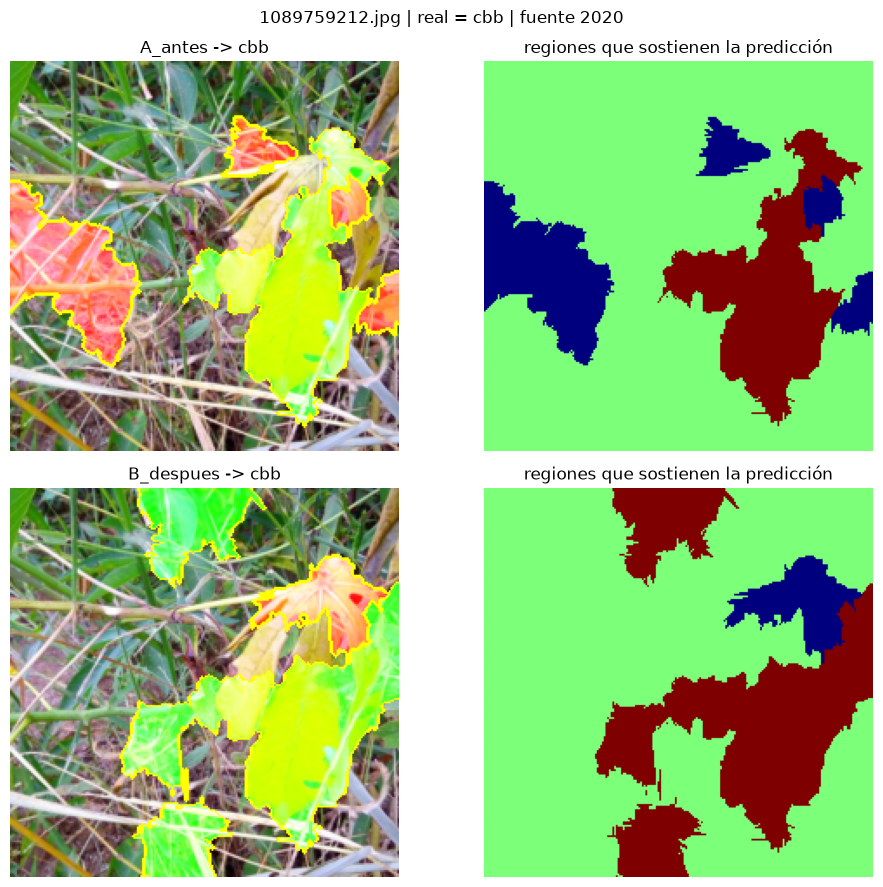

100%|██████████| 500/500 [00:01<00:00, 270.31it/s]


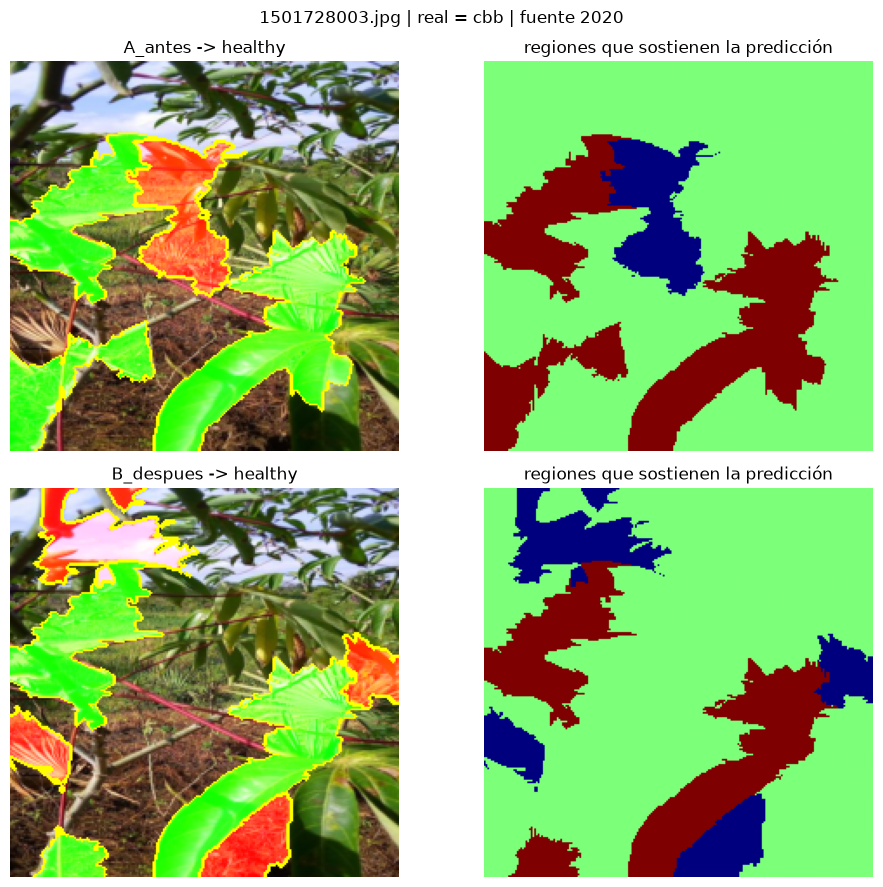

100%|██████████| 500/500 [00:01<00:00, 284.02it/s]


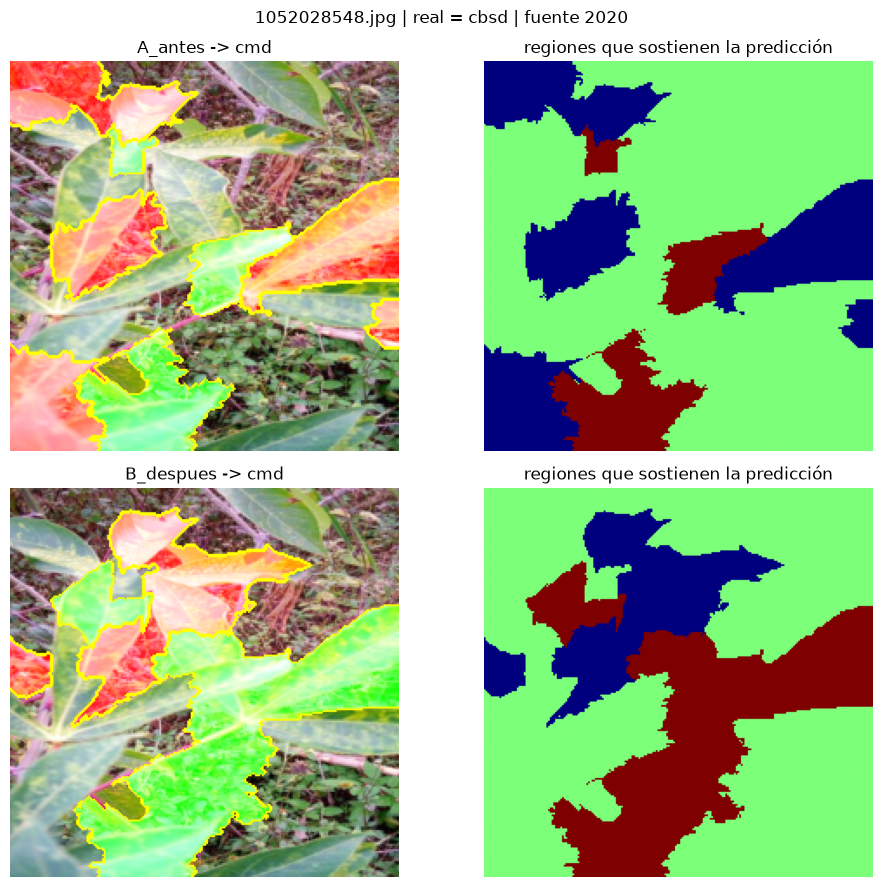

100%|██████████| 500/500 [00:01<00:00, 277.60it/s]


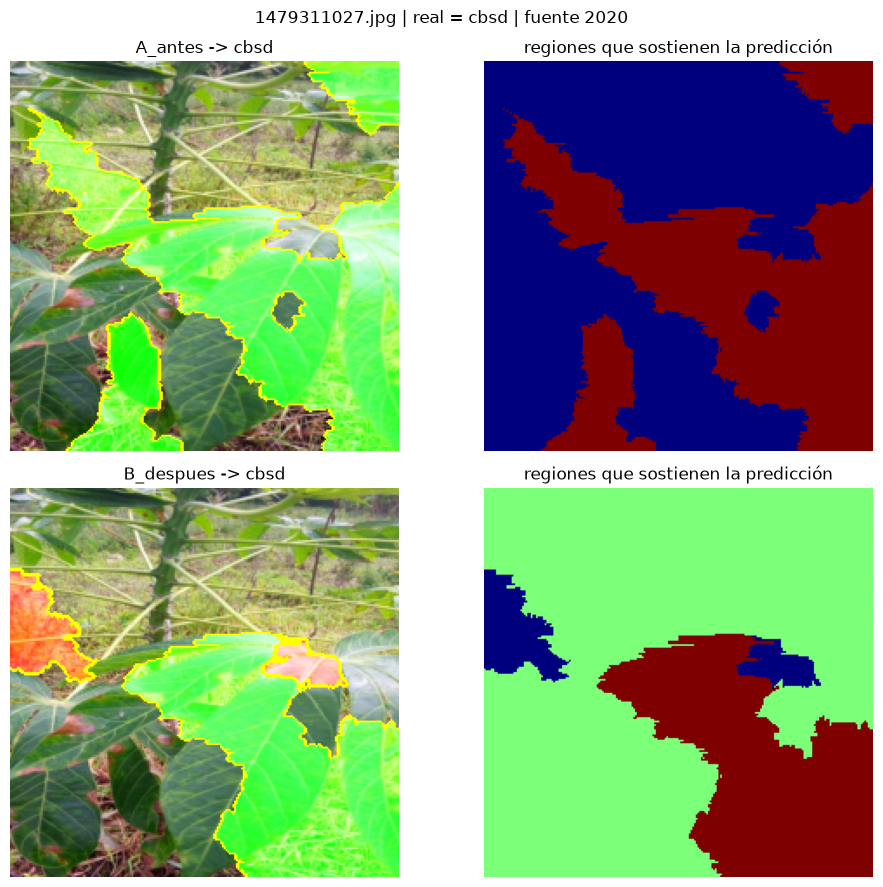

100%|██████████| 500/500 [00:01<00:00, 262.62it/s]


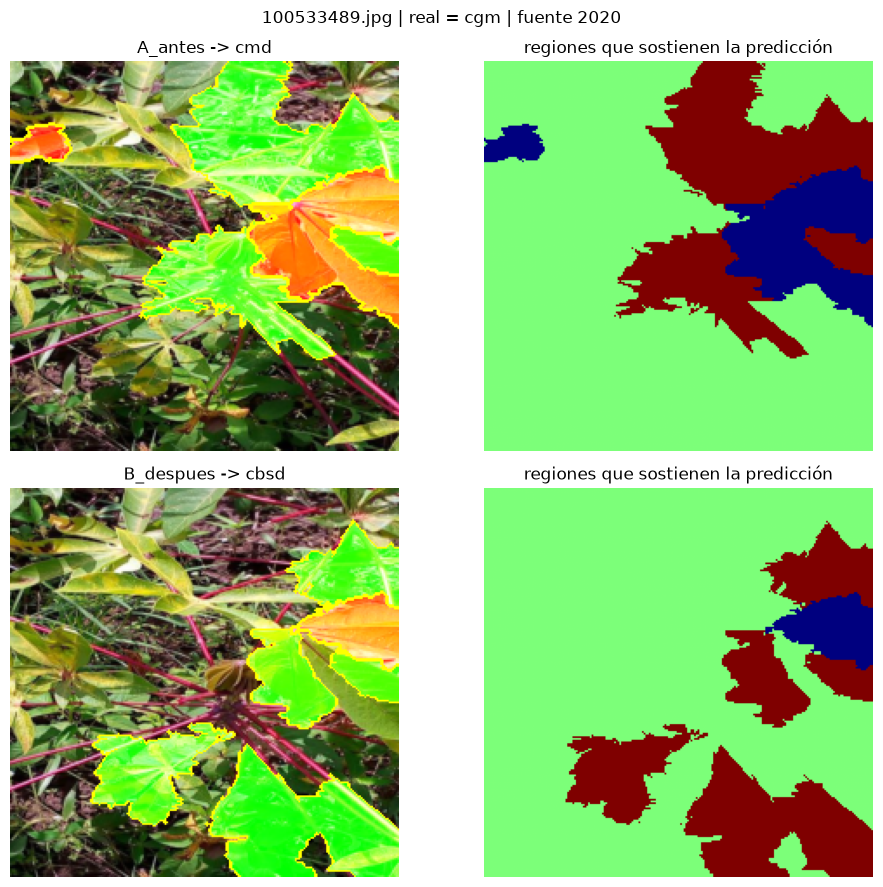

100%|██████████| 500/500 [00:01<00:00, 280.70it/s]


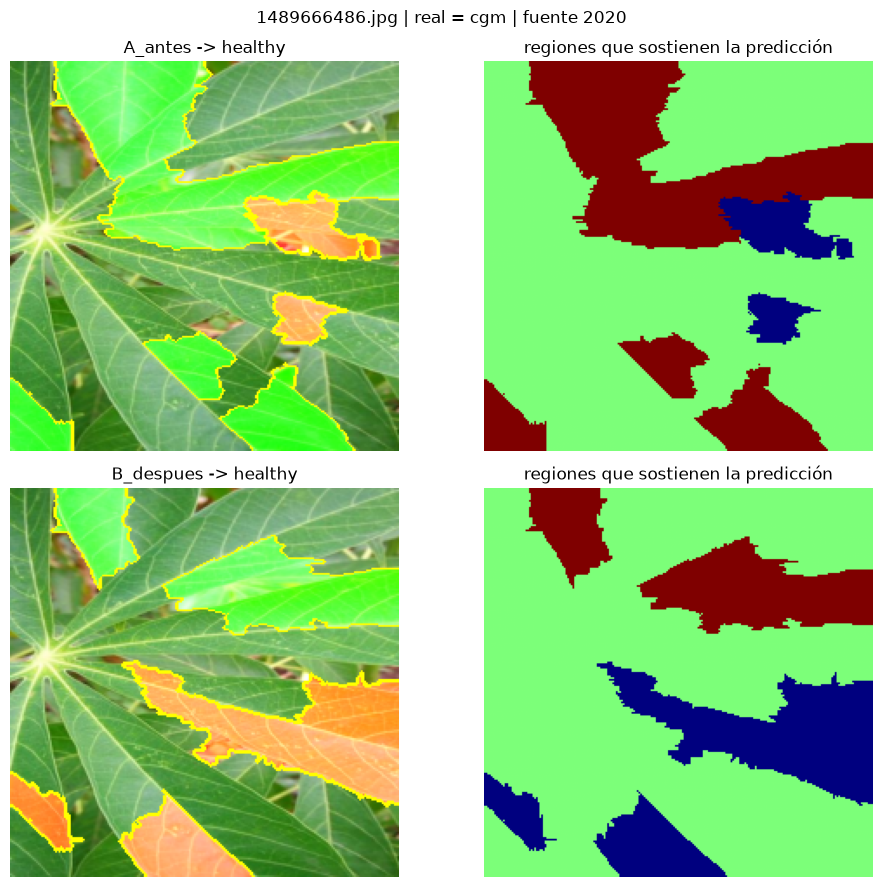

100%|██████████| 500/500 [00:01<00:00, 283.07it/s]


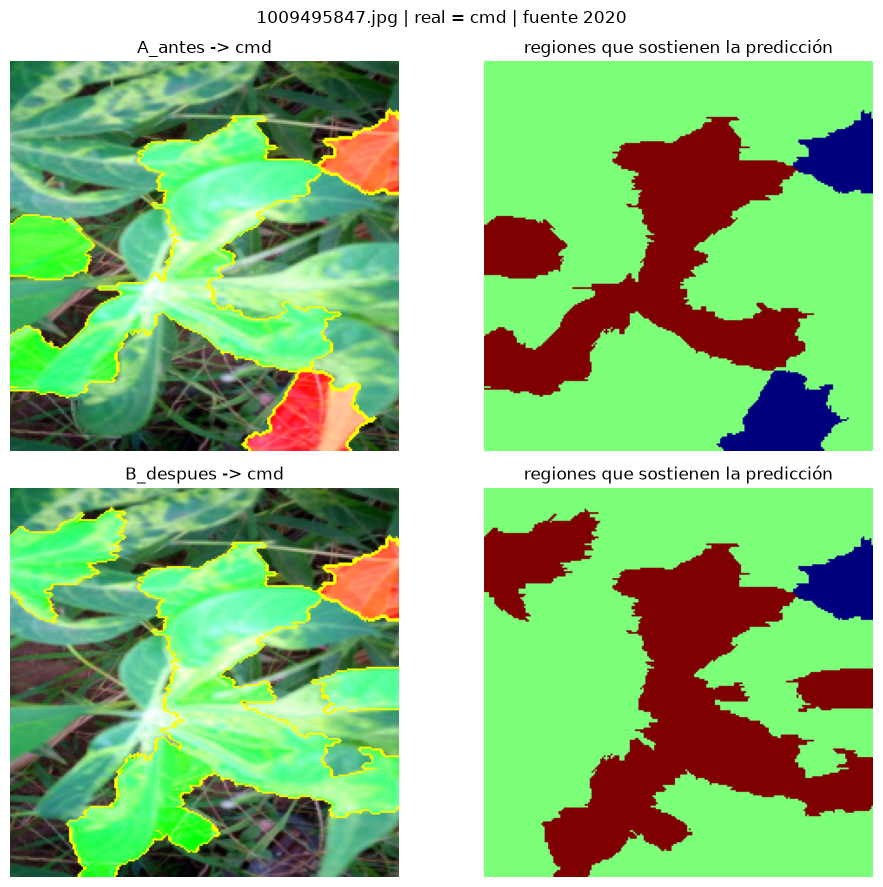

100%|██████████| 500/500 [00:01<00:00, 278.75it/s]


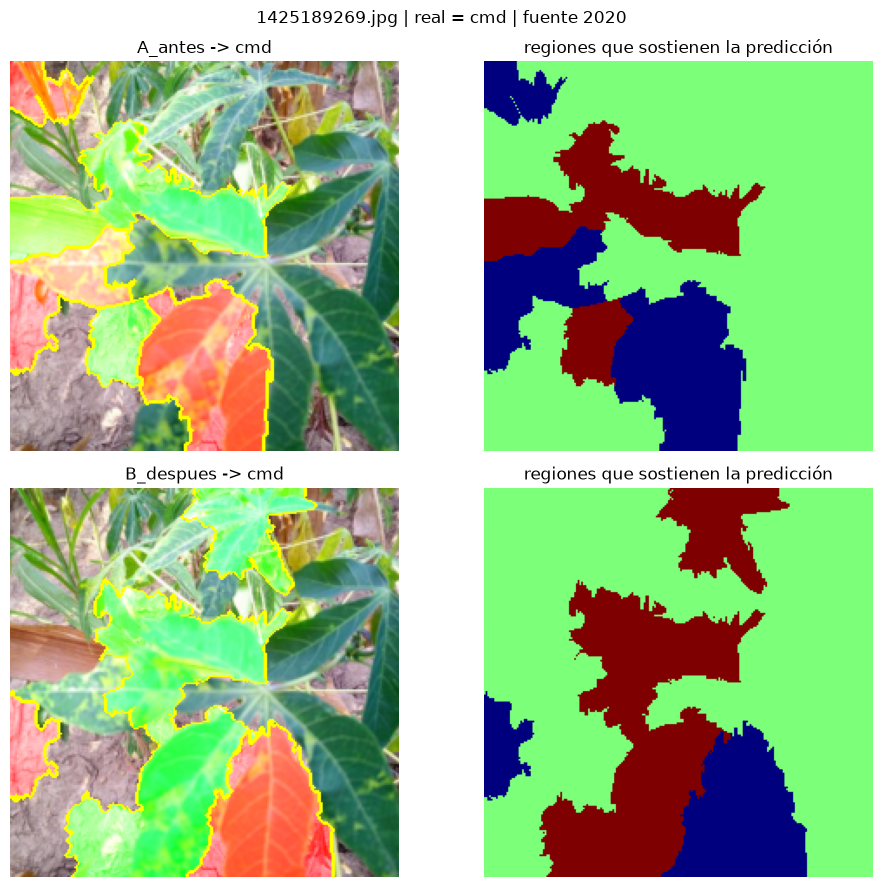

100%|██████████| 500/500 [00:01<00:00, 281.72it/s]


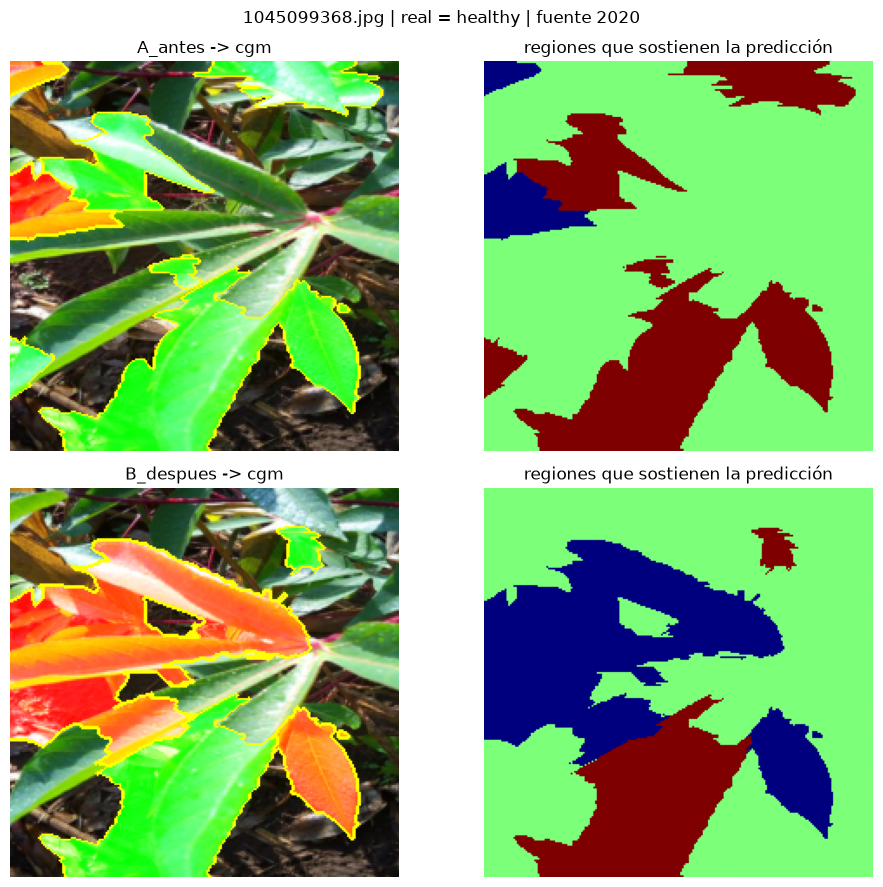

100%|██████████| 500/500 [00:01<00:00, 278.07it/s]


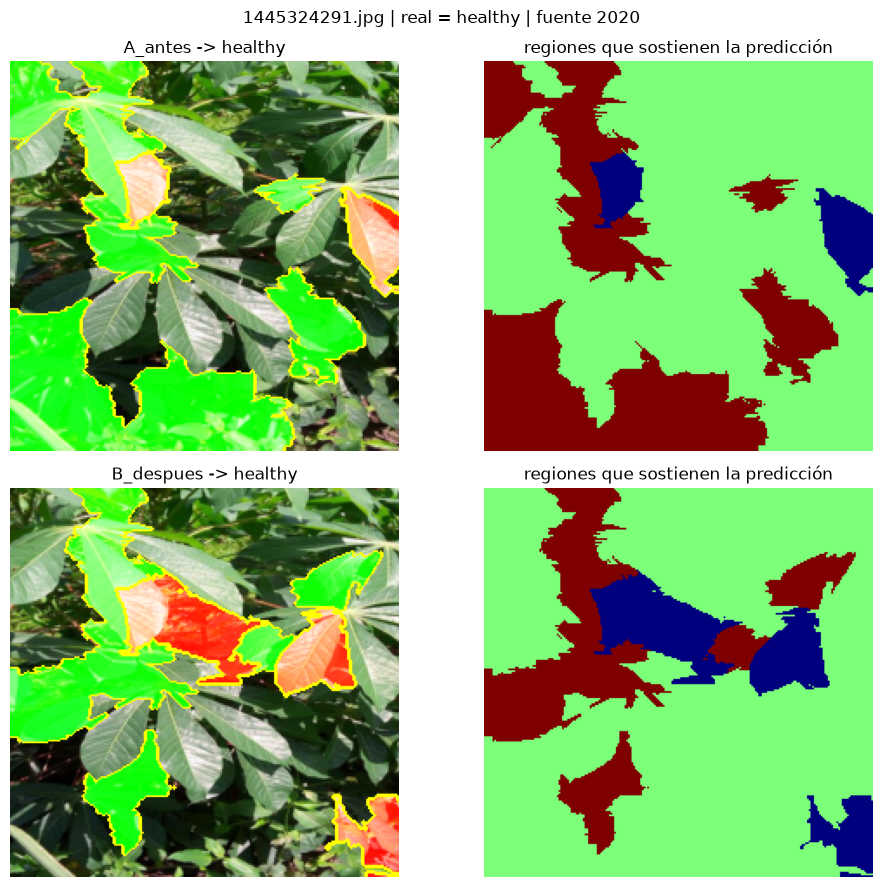

,image_id,clase_real,fuente,modelo,predicha
0,1089759212.jpg,cbb,2020,A_antes,cbb
1,1089759212.jpg,cbb,2020,B_despues,cbb
2,1501728003.jpg,cbb,2020,A_antes,healthy
3,1501728003.jpg,cbb,2020,B_despues,healthy
4,1052028548.jpg,cbsd,2020,A_antes,cmd
5,1052028548.jpg,cbsd,2020,B_despues,cmd
6,1479311027.jpg,cbsd,2020,A_antes,cbsd
7,1479311027.jpg,cbsd,2020,B_despues,cbsd
8,100533489.jpg,cgm,2020,A_antes,cmd
9,100533489.jpg,cgm,2020,B_despues,cbsd


In [24]:
lime_dir = DIR_REPORT / "lime_antes_despues"
lime_dir.mkdir(parents=True, exist_ok=True)
muestras_lime = []

for i, row in muestra.iterrows():
    img_pil = Image.open(DIR_IMG / row["image_id"]).convert("RGB")
    img = np.asarray(tf_vis(img_pil), dtype=np.float32) / 255.0

    ex = {}
    for etiqueta, fn in [("A_antes", fn_A), ("B_despues", fn_B)]:
        explanation = explainer.explain_instance(
            img, fn, top_labels=NUM_CLASSES, hide_color=0,
            num_samples=LIME_SAMPLES, random_seed=SEED)
        top = explanation.top_labels[0]
        temp, mask = explanation.get_image_and_mask(
            top, positive_only=False, num_features=10, hide_rest=False)
        ex[etiqueta] = (top, temp, mask)
        muestras_lime.append(dict(image_id=row["image_id"], clase_real=row["label_name"],
                                  fuente=str(row["source"]), modelo=etiqueta,
                                  predicha=CLASS_NAMES[top], probs=fn(img[None])[0].round(3).tolist()))

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for r_, (etiqueta, (top, temp, mask)) in zip(range(2), ex.items()):
        axes[r_, 0].imshow(mark_boundaries(temp, mask))
        axes[r_, 0].set_title(f"{etiqueta} -> {CLASS_NAMES[top]}")
        axes[r_, 1].imshow(mask, cmap="jet")
        axes[r_, 1].set_title("regiones que sostienen la predicción")
    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(f"{row['image_id']} | real = {row['label_name']} | fuente {row['source']}")
    plt.tight_layout()
    plt.savefig(lime_dir / f"lime_{i:02d}_{row['label_name']}.png", dpi=110)
    plt.show()

df_lime = pd.DataFrame(muestras_lime)
display(df_lime[["image_id", "clase_real", "fuente", "modelo", "predicha"]])

In [25]:
def metricas_por_fuente(res):
    te = res["test"]
    y_true = np.array(te["y_true"]); y_pred = np.array(te["y_pred"])
    src = df_test["source"].astype(str).values
    out = {}
    for s in ["2019", "2020"]:
        m = src == s
        if m.sum() > 0:
            out[f"F1_{s}"] = float(f1_score(y_true[m], y_pred[m], average="macro", zero_division=0))
            out[f"Rec_enf_{s}"] = metricas_fn(y_true[m], y_pred[m])["recall_enf"]
            out[f"n_{s}"] = int(m.sum())
    return out

tabla_fuente = pd.DataFrame([
    dict(Modelo=etq, **metricas_por_fuente(r))
    for etq, r in [(f"{mejor_mv2} (antes FT)", RESULTADOS[mejor_mv2]),
                   ("E5 (despues FT)", RESULTADOS["E5"])]])
display(tabla_fuente.round(4))
print("Nota: la fuente 2019 tiene pocas imagenes en el test (n chico) -> comparar con cautela.")

,Modelo,F1_2019,Rec_enf_2019,n_2019,F1_2020,Rec_enf_2020,n_2020
0,E1 (antes FT),0.5911,0.8929,61,0.6157,0.9185,239
1,E5 (despues FT),0.6685,0.9286,61,0.6454,0.8750,239


Nota: la fuente 2019 tiene pocas imagenes en el test (n chico) -> comparar con cautela.


## Fase 7 — Reporte global: tabla de todo lo probado, con umbral calibrado

Se ensamblan todos los `*_v2_res.json` (E1-E5 + E6-E9 por backbone) y, **para cada modelo**:

1. se calibra `tau` **solo con validación** (menor `tau` con recall enfermo ≥ `OBJ_RECALL`);
2. se aplica ese `tau` al **test balanceado** (300) y al **test extendido** (`test_pool_rest`);
3. se reporta recall enfermo con IC de Wilson, especificidad y AUC binaria, junto al macro-F1.

El "mejor modelo" se elige **por validación** (mayor especificidad con recall objetivo cumplido), no por test.

In [26]:
RES_BY_ID = {}
for f in sorted(DIR_MODEL.glob(f"*{TAG}_res.json")):
    r = json.loads(f.read_text(encoding="utf-8"))
    if r["id"] == "E5":
        RES_BY_ID["E5a"] = json.loads((DIR_MODEL / f"{r['antes']}{TAG}_res.json").read_text(encoding="utf-8"))
        RES_BY_ID["E5b"] = r
    else:
        RES_BY_ID[r["id"]] = r

METODO = {"E5a": "MV2 cabeza (antes FT)", "E5b": "MV2 fine-tuning (despues)"}


def evaluar_tau(r, objetivo=OBJ_RECALL):
    # Calibra tau en val y lo aplica a test y test_ext (nunca se ajusta con test).
    yv = np.array(r["val"]["y_true"]); pv = np.array(r["val"]["probs"])
    tau = elegir_tau(pv, yv, objetivo)
    out = dict(tau=tau, val=metricas_fn(yv, predecir_con_umbral(pv, tau)))
    for k in ("test", "test_ext"):
        m = r.get(k)
        out[k] = (metricas_fn(m["y_true"], predecir_con_umbral(np.array(m["probs"]), tau)) if m else None)
    return out


def fila_res(id_, r, metodo=None):
    t = evaluar_tau(r)
    nan = float("nan")
    ex = t["test_ext"]
    return dict(ID=id_, Metodo=metodo or METODO.get(id_) or r.get("metodo"), Backbone=r.get("backbone"),
                Input=r.get("size"), Aug=(("si" if r["aug"] else "no") if r.get("aug") is not None else "-"),
                Epocas=r.get("epochs_run"), Params=r.get("params"), s_epoc=r.get("tiempo_ep_s"),
                F1_val=r["val"]["f1_macro"], AUC_val=r["val"]["auc_enf"],
                F1_test=r["test"]["f1_macro"], BalAcc=r["test"]["balanced_acc"], AUC_enf=r["test"]["auc_enf"],
                Rec_enf_argmax=r["test"]["recall_enf"], Esp_argmax=r["test"]["especificidad"],
                tau=t["tau"], Rec_val_tau=t["val"]["recall_enf"], Esp_val_tau=t["val"]["especificidad"],
                Rec_enf_tau=t["test"]["recall_enf"], Rec_IC_lo=t["test"]["recall_enf_ic"][0],
                Rec_IC_hi=t["test"]["recall_enf_ic"][1], Esp_tau=t["test"]["especificidad"],
                Rec_ext_tau=ex["recall_enf"] if ex else nan, Esp_ext_tau=ex["especificidad"] if ex else nan,
                n_ext=(ex["tp"] + ex["fn"] + ex["tn"] + ex["fp"]) if ex else 0,
                **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)})


orden_ids = ["E1", "E2", "E3", "E4", "E5a", "E5b",
             "E6_mobilenetv2", "E7_mobilenetv2", "E8_mobilenetv2", "E9_mobilenetv2",
             "E6_efficientnet", "E7_efficientnet", "E8_efficientnet", "E9_efficientnet"]
df_res = pd.DataFrame([fila_res(i, RES_BY_ID[i]) for i in orden_ids if i in RES_BY_ID])

cols_main = ["ID", "Metodo", "Backbone", "Input", "Aug", "Epocas", "F1_val", "AUC_val", "F1_test", "BalAcc", "AUC_enf"]
cols_fn = ["ID", "Rec_enf_argmax", "Esp_argmax", "tau", "Rec_val_tau", "Esp_val_tau",
           "Rec_enf_tau", "Rec_IC_lo", "Rec_IC_hi", "Esp_tau", "Rec_ext_tau", "Esp_ext_tau", "n_ext"]
print("== discriminacion (5 clases) y AUC binaria ==")
display(df_res[cols_main].round(4))
print(f"== objetivo: recall enfermo >= {OBJ_RECALL} (tau calibrado en val; test sin tocar) ==")
display(df_res[cols_fn].round(4))

== discriminacion (5 clases) y AUC binaria ==


,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,AUC_val,F1_test,BalAcc,AUC_enf
0,E1,transfer learning (cabeza),mobilenetv2_100,224.0,no,17.0,0.6006,0.9025,0.6165,0.6200,0.8451
1,E2,transfer learning (cabeza),mobilenetv2_100,224.0,si,16.0,0.5961,0.8959,0.5988,0.6100,0.8444
2,E3,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,no,9.0,0.6251,0.9190,0.6209,0.6300,0.8515
3,E4,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,si,9.0,0.6312,0.9270,0.6235,0.6333,0.8565
4,E5a,MV2 cabeza (antes FT),mobilenetv2_100,224.0,no,17.0,0.6006,0.9025,0.6165,0.6200,0.8451
5,E5b,MV2 fine-tuning (despues),mobilenetv2_100,224.0,si,12.0,0.6453,0.9381,0.6502,0.6533,0.8450
6,E6_mobilenetv2,RandomForest,mobilenetv2_100,NaN,-,NaN,0.5331,0.8721,0.4927,0.5033,0.8093
7,E7_mobilenetv2,SVM RBF,mobilenetv2_100,NaN,-,NaN,0.6214,0.8930,0.4854,0.5000,0.8101
8,E8_mobilenetv2,XGBoost,mobilenetv2_100,NaN,-,NaN,0.5909,0.9025,0.5388,0.5467,0.8102
9,E9_mobilenetv2,MLP (red sobre embeddings),mobilenetv2_100,NaN,-,NaN,0.6389,0.9121,0.5260,0.5367,0.7818


== objetivo: recall enfermo >= 0.95 (tau calibrado en val; test sin tocar) ==


,ID,Rec_enf_argmax,Esp_argmax,tau,Rec_val_tau,Esp_val_tau,Rec_enf_tau,Rec_IC_lo,Rec_IC_hi,Esp_tau,Rec_ext_tau,Esp_ext_tau,n_ext
0,E1,0.9125,0.6167,0.38,0.9533,0.5269,0.9208,0.8797,0.9487,0.5333,0.9670,0.5893,752
1,E2,0.8875,0.6500,0.44,0.9519,0.5054,0.9125,0.8699,0.9421,0.5167,0.9684,0.6071,752
2,E3,0.9125,0.5000,0.38,0.9519,0.5269,0.9208,0.8797,0.9487,0.4500,0.9756,0.5357,752
3,E4,0.9375,0.5333,0.31,0.9519,0.5806,0.9292,0.8895,0.9553,0.5833,0.9756,0.6071,752
4,E5a,0.9125,0.6167,0.38,0.9533,0.5269,0.9208,0.8797,0.9487,0.5333,0.9670,0.5893,752
5,E5b,0.8875,0.5667,0.39,0.9506,0.6452,0.8958,0.8508,0.9284,0.6000,0.9670,0.6071,752
6,E6_mobilenetv2,0.9708,0.3000,0.27,0.9586,0.3441,0.9458,0.9095,0.9681,0.4167,0.9784,0.4643,752
7,E7_mobilenetv2,0.8792,0.4500,0.32,0.9546,0.5484,0.8708,0.8225,0.9075,0.5667,0.9612,0.6250,752
8,E8_mobilenetv2,0.9208,0.4333,0.36,0.9533,0.4946,0.9083,0.8651,0.9387,0.4833,0.9741,0.5893,752
9,E9_mobilenetv2,0.8792,0.4667,0.42,0.9506,0.5914,0.8750,0.8272,0.9110,0.4833,0.9454,0.6250,752


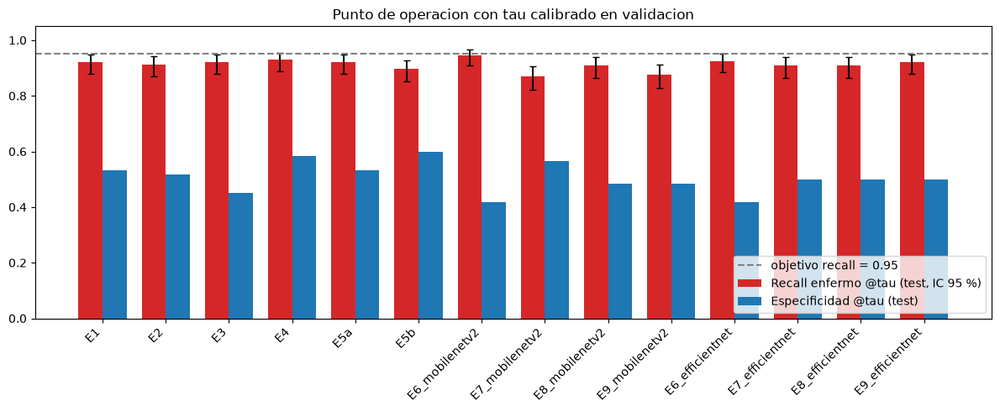

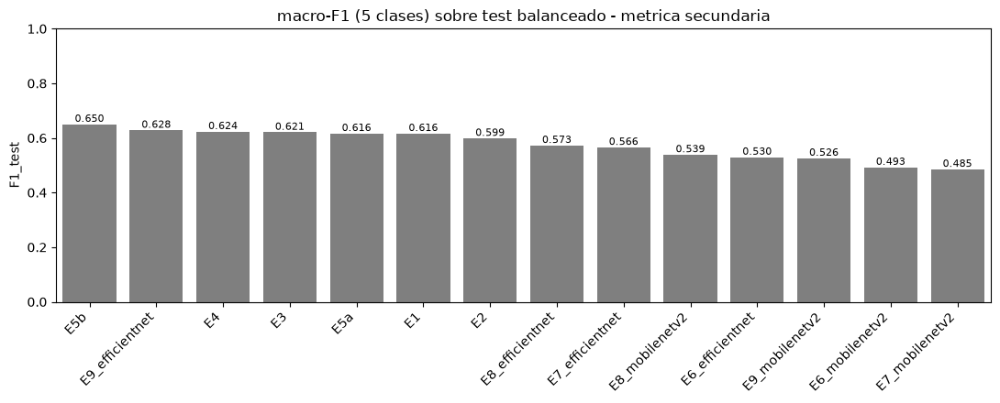

In [27]:
d = df_res.dropna(subset=["Rec_enf_tau"]).reset_index(drop=True)
x = np.arange(len(d)); w = 0.38
yerr = np.array([d["Rec_enf_tau"] - d["Rec_IC_lo"], d["Rec_IC_hi"] - d["Rec_enf_tau"]])
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w / 2, d["Rec_enf_tau"], w, yerr=yerr, capsize=3, label="Recall enfermo @tau (test, IC 95 %)", color="tab:red")
ax.bar(x + w / 2, d["Esp_tau"], w, label="Especificidad @tau (test)", color="tab:blue")
ax.axhline(OBJ_RECALL, ls="--", color="gray", label=f"objetivo recall = {OBJ_RECALL}")
ax.set_xticks(x); ax.set_xticklabels(d["ID"], rotation=45, ha="right")
ax.set_ylim(0, 1.05); ax.set_title("Punto de operacion con tau calibrado en validacion")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 4.5))
o = df_res.sort_values("F1_test", ascending=False)
ax = sns.barplot(data=o, x="ID", y="F1_test", color="tab:gray")
ax.set_title("macro-F1 (5 clases) sobre test balanceado - metrica secundaria"); ax.set_ylim(0, 1); ax.set_xlabel("")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

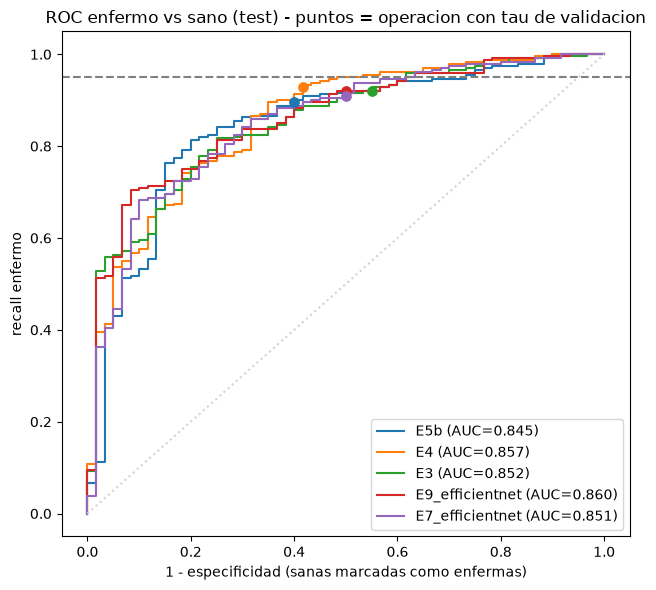

In [28]:
top = df_res.sort_values("AUC_val", ascending=False).head(5)["ID"].tolist()    # elegidos por validacion
plt.figure(figsize=(6.5, 6))
for i in top:
    r = RES_BY_ID[i]["test"]
    enf = (np.array(r["y_true"]) != HEALTHY).astype(int)
    score = 1 - np.array(r["probs"])[:, HEALTHY]
    fpr, tpr, _ = roc_curve(enf, score)
    plt.plot(fpr, tpr, label=f"{i} (AUC={r['auc_enf']:.3f})")
    fila = df_res[df_res.ID == i].iloc[0]
    plt.scatter([1 - fila["Esp_tau"]], [fila["Rec_enf_tau"]], marker="o", s=45, zorder=5)
plt.axhline(OBJ_RECALL, ls="--", color="gray")
plt.plot([0, 1], [0, 1], ":", color="lightgray")
plt.xlabel("1 - especificidad (sanas marcadas como enfermas)"); plt.ylabel("recall enfermo")
plt.title("ROC enfermo vs sano (test) - puntos = operacion con tau de validacion")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### Ensamble y TTA

- **Ensamble**: promedio de probabilidades de los 3 mejores modelos por **AUC binaria de validación** (las probabilidades de val/test están guardadas y alineadas, por lo que no hace falta reinferir).
- **TTA**: E5 evaluado promediando predicción original + flip horizontal + flip vertical.

In [29]:
def combinar(ids, nombre):
    rs = [RES_BY_ID[i] for i in ids]
    out = dict(id=nombre, metodo=f"Ensamble ({'+'.join(ids)})", backbone="+".join(ids),
               size=None, aug=None, epochs_run=None, params=None, tiempo_ep_s=None)
    for k in ("val", "test", "test_ext"):
        ms = [r.get(k) for r in rs]
        if any(m is None for m in ms):
            out[k] = None
            continue
        assert all(m["y_true"] == ms[0]["y_true"] for m in ms), "orden de muestras distinto entre modelos"
        out[k] = calc_metricas(ms[0]["y_true"], np.mean([np.array(m["probs"]) for m in ms], axis=0))
    return out

ids_ens = df_res.sort_values("AUC_val", ascending=False).head(3)["ID"].tolist()
print("ensamble con:", ids_ens)
RES_BY_ID["ENS"] = combinar(ids_ens, "ENS")

# --- TTA sobre E5 ---
cfg_b = CONFIG[mejor_mv2]
modelo_tta = Clf(cfg_b["backbone"]).to(DEVICE)
modelo_tta.load_state_dict(torch.load(DIR_MODEL / f"E5{TAG}.pth", map_location=DEVICE))
tf_ev = build_transforms(cfg_b["size"], False)
r_tta = dict(id="E5b_TTA", metodo="MV2 fine-tuning + TTA", backbone=cfg_b["backbone"], size=cfg_b["size"],
             aug=True, epochs_run=None, params=None, tiempo_ep_s=None)
for k, sp in [("val", "val"), ("test", "test"), ("test_ext", "test_pool_rest")]:
    r_tta[k] = evaluar(modelo_tta, MandiocaDataset(manifest, sp, tf_ev), batch_size=64, tta=True)
RES_BY_ID["E5b_TTA"] = r_tta

df_extra = pd.DataFrame([fila_res("ENS", RES_BY_ID["ENS"], metodo=RES_BY_ID["ENS"]["metodo"]),
                         fila_res("E5b_TTA", r_tta)])
df_res = pd.concat([df_res, df_extra], ignore_index=True)
display(df_extra[cols_main + cols_fn[1:]].round(4))

ensamble con: ['E5b', 'E4', 'E3']


d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
d:\final_inteligencia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,AUC_val,F1_test,BalAcc,...,tau,Rec_val_tau,Esp_val_tau,Rec_enf_tau,Rec_IC_lo,Rec_IC_hi,Esp_tau,Rec_ext_tau,Esp_ext_tau,n_ext
0,ENS,Ensamble (E5b+E4+E3),E5b+E4+E3,NaN,-,None,0.6972,0.9444,0.6676,0.6733,...,0.33,0.9519,0.6344,0.9125,0.8699,0.9421,0.6500,0.9727,0.6964,752
1,E5b_TTA,MV2 fine-tuning + TTA,mobilenetv2_100,224.0,si,None,0.6495,0.9357,0.6611,0.6633,...,0.38,0.9506,0.6667,0.8917,0.8460,0.9250,0.5833,0.9641,0.6607,752


In [30]:
cand = df_res[df_res["Esp_val_tau"].notna()]
cand_ok = cand[cand["Rec_val_tau"] >= OBJ_RECALL - 1e-9]       # modelos que cumplen el objetivo en VAL
pool = cand_ok if len(cand_ok) else cand
mejor = pool.sort_values(["Esp_val_tau", "AUC_val"], ascending=False).iloc[0]   # elegido por validacion
mejor_f1 = df_res.loc[df_res["F1_val"].idxmax()]
ml_rows = df_res[df_res["Metodo"].astype(str).str.contains("RandomForest|SVM|XGBoost|MLP")]
mejor_ml = ml_rows.loc[ml_rows["AUC_val"].idxmax()] if len(ml_rows) else None
ab = df_res.set_index("ID")
delta_ft = float(ab.loc["E5b", "F1_test"] - ab.loc["E5a", "F1_test"])
delta_rec = float(ab.loc["E5b", "Rec_enf_tau"] - ab.loc["E5a", "Rec_enf_tau"])

tabla_md = "\n".join(
    f"| {r.ID} | {r.Metodo} | {r.F1_test:.3f} | {r.AUC_enf:.3f} | {r.Rec_enf_argmax:.3f} | "
    f"{r.Rec_enf_tau:.3f} [{r.Rec_IC_lo:.3f}-{r.Rec_IC_hi:.3f}] | {r.Esp_tau:.3f} | {r.Rec_ext_tau:.3f} |"
    for r in df_res.itertuples())

lineas = [
    "### §6 — Resultados de entrenamiento (v2, priorizando falsos negativos)",
    "",
    f"**Objetivo:** recall de 'enfermo' >= {OBJ_RECALL} (tau calibrado en validación). "
    "Test balanceado: 300 imágenes (60 por clase), semilla 42, sin fuga (ver notebook 02). "
    "Test extendido: imágenes held-out de `test_pool_rest` (no balanceado).",
    "",
    "| ID | Método | macro-F1 test | AUC enf-vs-sana | Recall enf (argmax) | Recall enf @tau [IC 95 %] | Especificidad @tau | Recall enf @tau (test ext.) |",
    "|---|---|---|---|---|---|---|---|",
    tabla_md,
    "",
    f"- **Mejor modelo para el objetivo (elegido por validación)**: `{mejor['ID']}` ({mejor['Metodo']}) → "
    f"recall enfermo en test = {mejor['Rec_enf_tau']:.3f} "
    f"[IC 95 % {mejor['Rec_IC_lo']:.3f}-{mejor['Rec_IC_hi']:.3f}], especificidad = {mejor['Esp_tau']:.3f}, tau = {mejor['tau']:.2f}.",
    f"- **Mejor por macro-F1 de validación (referencia)**: `{mejor_f1['ID']}` ({mejor_f1['Metodo']}), "
    f"macro-F1 test = {mejor_f1['F1_test']:.3f}.",
    f"- **Fine-tuning MobileNetV2 (E5)**: macro-F1 test {ab.loc['E5a', 'F1_test']:.3f} → {ab.loc['E5b', 'F1_test']:.3f} "
    f"(Δ = {delta_ft:+.3f}); recall enfermo @tau {ab.loc['E5a', 'Rec_enf_tau']:.3f} → {ab.loc['E5b', 'Rec_enf_tau']:.3f} (Δ = {delta_rec:+.3f}).",
]
if mejor_ml is not None:
    lineas.append(f"- **Ítem 4 — mejor clásico (por AUC val)**: `{mejor_ml['ID']}` ({mejor_ml['Metodo']} sobre "
                  f"{mejor_ml['Backbone']}), AUC enf test = {mejor_ml['AUC_enf']:.3f}, "
                  f"recall enfermo @tau = {mejor_ml['Rec_enf_tau']:.3f}.")
fte = tabla_fuente.set_index("Modelo")
for etq in fte.index:
    lineas.append(f"- **Sesgo de fuente** ({etq}): macro-F1 2019 / 2020 = "
                  f"{fte.loc[etq, 'F1_2019']:.3f} / {fte.loc[etq, 'F1_2020']:.3f}; recall enfermo (argmax) = "
                  f"{fte.loc[etq, 'Rec_enf_2019']:.3f} / {fte.loc[etq, 'Rec_enf_2020']:.3f} "
                  f"(n 2019 = {int(fte.loc[etq, 'n_2019'])}, n chico).")
lineas += [
    "- **LIME**: 20 explicaciones (10 imágenes del test balanceado × checkpoints A/B) en `reportes/lime_antes_despues/`. "
    "La interpretación (si las regiones resaltadas son hoja/síntomas o fondo/marco) debe verificarse visualmente "
    "y redactarse a mano; no se afirma aquí ausencia de sesgo espurio.",
    "- **Limitaciones**: con 240 enfermas en el test, el IC 95 % del recall es de aproximadamente ±4 puntos; "
    "las diferencias menores no son concluyentes. `tau` se calibró en validación y la especificidad resultante "
    "es el costo (plantas sanas marcadas como enfermas) de exigir ese recall.",
    "",
    "Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).",
]
txt = "\n".join(lineas)
display(Markdown(txt))

if not SMOKE:
    csv_out = DIR_REPORT / "02_resultados_experimentos_v2.csv"
    df_res.to_csv(csv_out, index=False)
    print("CSV:", csv_out)
    path_md = DIR_REPORT / "00_resumen_consigna_y_avance.md"
    contenido = path_md.read_text(encoding="utf-8") if path_md.exists() else ""
    ini, fin = "<!-- INICIO-RESULTADOS-TL -->", "<!-- FIN-RESULTADOS-TL -->"
    bloque = ini + "\n" + txt + "\n" + fin
    if ini in contenido and fin in contenido:
        pre = contenido[:contenido.index(ini)]
        post = contenido[contenido.index(fin) + len(fin):]
        contenido = pre + bloque + post
    else:
        contenido = contenido.rstrip() + "\n\n---\n\n" + bloque + "\n"
    path_md.write_text(contenido, encoding="utf-8")
    print("§6 actualizado en", path_md)

### §6 — Resultados de entrenamiento (v2, priorizando falsos negativos)

**Objetivo:** recall de 'enfermo' >= 0.95 (tau calibrado en validación). Test balanceado: 300 imágenes (60 por clase), semilla 42, sin fuga (ver notebook 02). Test extendido: imágenes held-out de `test_pool_rest` (no balanceado).

| ID | Método | macro-F1 test | AUC enf-vs-sana | Recall enf (argmax) | Recall enf @tau [IC 95 %] | Especificidad @tau | Recall enf @tau (test ext.) |
|---|---|---|---|---|---|---|---|
| E1 | transfer learning (cabeza) | 0.616 | 0.845 | 0.912 | 0.921 [0.880-0.949] | 0.533 | 0.967 |
| E2 | transfer learning (cabeza) | 0.599 | 0.844 | 0.887 | 0.912 [0.870-0.942] | 0.517 | 0.968 |
| E3 | transfer learning (cabeza) | 0.621 | 0.852 | 0.912 | 0.921 [0.880-0.949] | 0.450 | 0.976 |
| E4 | transfer learning (cabeza) | 0.624 | 0.857 | 0.938 | 0.929 [0.890-0.955] | 0.583 | 0.976 |
| E5a | MV2 cabeza (antes FT) | 0.616 | 0.845 | 0.912 | 0.921 [0.880-0.949] | 0.533 | 0.967 |
| E5b | MV2 fine-tuning (despues) | 0.650 | 0.845 | 0.887 | 0.896 [0.851-0.928] | 0.600 | 0.967 |
| E6_mobilenetv2 | RandomForest | 0.493 | 0.809 | 0.971 | 0.946 [0.910-0.968] | 0.417 | 0.978 |
| E7_mobilenetv2 | SVM RBF | 0.485 | 0.810 | 0.879 | 0.871 [0.822-0.907] | 0.567 | 0.961 |
| E8_mobilenetv2 | XGBoost | 0.539 | 0.810 | 0.921 | 0.908 [0.865-0.939] | 0.483 | 0.974 |
| E9_mobilenetv2 | MLP (red sobre embeddings) | 0.526 | 0.782 | 0.879 | 0.875 [0.827-0.911] | 0.483 | 0.945 |
| E6_efficientnet | RandomForest | 0.530 | 0.808 | 0.946 | 0.925 [0.885-0.952] | 0.417 | 0.978 |
| E7_efficientnet | SVM RBF | 0.566 | 0.851 | 0.892 | 0.908 [0.865-0.939] | 0.500 | 0.978 |
| E8_efficientnet | XGBoost | 0.573 | 0.839 | 0.904 | 0.908 [0.865-0.939] | 0.500 | 0.981 |
| E9_efficientnet | MLP (red sobre embeddings) | 0.628 | 0.860 | 0.867 | 0.921 [0.880-0.949] | 0.500 | 0.966 |
| ENS | Ensamble (E5b+E4+E3) | 0.668 | 0.876 | 0.917 | 0.912 [0.870-0.942] | 0.650 | 0.973 |
| E5b_TTA | MV2 fine-tuning + TTA | 0.661 | 0.848 | 0.900 | 0.892 [0.846-0.925] | 0.583 | 0.964 |

- **Mejor modelo para el objetivo (elegido por validación)**: `E5b_TTA` (MV2 fine-tuning + TTA) → recall enfermo en test = 0.892 [IC 95 % 0.846-0.925], especificidad = 0.583, tau = 0.38.
- **Mejor por macro-F1 de validación (referencia)**: `ENS` (Ensamble (E5b+E4+E3)), macro-F1 test = 0.668.
- **Fine-tuning MobileNetV2 (E5)**: macro-F1 test 0.616 → 0.650 (Δ = +0.034); recall enfermo @tau 0.921 → 0.896 (Δ = -0.025).
- **Ítem 4 — mejor clásico (por AUC val)**: `E9_efficientnet` (MLP (red sobre embeddings) sobre tf_efficientnet_b7.ra_in1k), AUC enf test = 0.860, recall enfermo @tau = 0.921.
- **Sesgo de fuente** (E1 (antes FT)): macro-F1 2019 / 2020 = 0.591 / 0.616; recall enfermo (argmax) = 0.893 / 0.918 (n 2019 = 61, n chico).
- **Sesgo de fuente** (E5 (despues FT)): macro-F1 2019 / 2020 = 0.669 / 0.645; recall enfermo (argmax) = 0.929 / 0.875 (n 2019 = 61, n chico).
- **LIME**: 20 explicaciones (10 imágenes del test balanceado × checkpoints A/B) en `reportes/lime_antes_despues/`. La interpretación (si las regiones resaltadas son hoja/síntomas o fondo/marco) debe verificarse visualmente y redactarse a mano; no se afirma aquí ausencia de sesgo espurio.
- **Limitaciones**: con 240 enfermas en el test, el IC 95 % del recall es de aproximadamente ±4 puntos; las diferencias menores no son concluyentes. `tau` se calibró en validación y la especificidad resultante es el costo (plantas sanas marcadas como enfermas) de exigir ese recall.

Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).

CSV: D:\final_inteligencia\reportes\02_resultados_experimentos_v2.csv
§6 actualizado en D:\final_inteligencia\reportes\00_resumen_consigna_y_avance.md


## Reproducibilidad y verificación

- **Semilla 42** en splits, entrenamiento (DataLoader con generator), SVM/RF/XGB/MLP y LIME.
- Splits en `datos\splits\manifest_20pct.csv` (idénticos a la v1: misma semilla y estratificación); checkpoints en `modelos\E1..E5_v2.pth`; métricas crudas **con probabilidades** en `modelos\*_v2_res.json`; embeddings `.npz` reutilizados de la v1. Si ya existen, las celdas **usan caché** y no reentrenan.
- Tabla consolidada: `reportes\02_resultados_experimentos_v2.csv`.
- **Qué se calibra con qué:** hiperparámetros, selección de checkpoint y `tau` usan **solo validación**; el test (balanceado y extendido) solo se usa para reportar.
- Ejecución completa:
  `python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=14400 02_transfer_learning_mandioca_v2.ipynb`
  (con el kernel del venv `.venv`; modo rápido de prueba: variable de entorno `SMOKE=1`).
- Exportación de código: `python -m nbconvert --to script 02_transfer_learning_mandioca_v2.ipynb`.